# **Medical Image Processing**
### Retinal Vessel Challenge

Group components:
* S345699 - Sebastiano Natali
* S345744 - Chiara Memoli
* S349049 - Chiara Guadagno
* S349089 - Fabio Galante


In [ ]:
# Install necessary libraries for advanced metrics
!pip install medpy skan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 14.5 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=bb15d723a3c951abeb0ddac01381c09a45cc621481680b66b50e13bff39059a8
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


# Starting points

## Mount drive, import libraries, define main directories

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Show versioning of deep learning libraries
import torch, torchvision
from torchsummary import summary
print(torch.__version__, torch.cuda.is_available())

2.9.0+cu126 True


In [ ]:
# import useful libraries
import os, cv2
import numpy as np
import pandas as pd
from skimage import color, filters
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [ ]:
# Project directories
project_dir = '/content/drive/MyDrive/MIP - project'

data_dir = os.path.join(project_dir, 'data')


train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

subfolders = ['image', 'manual', 'manual_py']

## 80/10/10 split of the dataset, unless a division of the original dataset is found

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from glob import glob

# Original dataset division
orig_data_dir = os.path.join(project_dir, 'Dataset_vessel_stu')
orig_train_dir = os.path.join(orig_data_dir, 'train')
orig_val_dir = os.path.join(orig_data_dir, 'val')


# Check if split already exists
if os.path.exists(train_dir) and os.listdir(train_dir):
    print("Data split already exists. Skipping data preparation step.")

else:
    print("Starting data split (80/10/10)...")

    # Get list of all images (from both original train and val subfolders)
    all_files = []

    # Returns a list of dicts: {'filename': name, 'image_path': path, 'mask_path': path, 'mask_py_path': path}
    def collect_files(base_dir):
        collected = []
        img_dir = os.path.join(base_dir, 'image')

        if os.path.exists(img_dir):
            for f in os.listdir(img_dir):
                if f.lower().endswith(('.png')):
                    item = {
                        'filename': f,
                        'image': os.path.join(base_dir, 'image', f),
                        'manual': os.path.join(base_dir, 'manual', f),
                        'manual_py': os.path.join(base_dir, 'manual_py', f)
                    }
                    # Ensure masks actually exist before adding
                    if os.path.exists(item['manual']) and os.path.exists(item['manual_py']):
                        collected.append(item)
                    else:
                        print(f"Warning: Missing manual ({item['manual']}) or manual_py ({item['manual_py']})")
        return collected

    # Collect from original train and val
    all_data = collect_files(orig_train_dir) + collect_files(orig_val_dir)
    print(f"Total images found: {len(all_data)}")


    # Split dataset: 80/10/10
    train_data, temp_data = train_test_split(all_data, test_size=0.2, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

    print(f"Split results: Train ({len(train_data)}), Val ({len(val_data)}), Test ({len(test_data)})")

    # Copy Files to New Structure
    def copy_dataset(dataset, destination_root):
        for item in dataset:
            for sub in subfolders:
                # Define src and dst
                src_path = item[sub]
                dst_dir = os.path.join(destination_root, sub)
                dst_path = os.path.join(dst_dir, item['filename'])

                # Create dir if not exists
                os.makedirs(dst_dir, exist_ok=True)

                # Copy
                shutil.copy2(src_path, dst_path)

    print("Copying training data...")
    copy_dataset(train_data, train_dir)

    print("Copying validation data...")
    copy_dataset(val_data, val_dir)

    print("Copying test data...")
    copy_dataset(test_data, test_dir)

    print("Data preparation complete!")

Data split already exists. Skipping data preparation step.


## Define UNet model (from lab03 - part2)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """Applies two consecutive conv-batchnorm-relu layers"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 init_filters=64,
                 depth=5,
                 bilinear=True):
        super(UNet, self).__init__()
        self.depth = depth
        self.down_layers = nn.ModuleList()
        self.up_layers = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Encoder
        filters = init_filters
        for d in range(depth):
            conv = DoubleConv(in_channels, filters)
            self.down_layers.append(conv)
            in_channels = filters
            filters *= 2

        # Bottleneck
        self.bottleneck = DoubleConv(in_channels, filters)

        # Decoder
        for d in range(depth):
            filters //= 2
            if bilinear:
                up = nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                    nn.Conv2d(filters * 2, filters, kernel_size=1)
                )
            else:
                up = nn.ConvTranspose2d(filters * 2, filters, kernel_size=2, stride=2)
            self.up_layers.append(nn.ModuleDict({
                'up': up,
                'conv': DoubleConv(filters * 2, filters)
            }))

        # Output layer
        self.out_conv = nn.Conv2d(init_filters, out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.down_layers:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for i in range(self.depth):
            skip = skip_connections[-(i+1)]
            up = self.up_layers[i]['up'](x)
            if up.size() != skip.size():
                # Resize in case of odd size mismatch
                up = F.interpolate(up, size=skip.shape[2:])
            x = torch.cat([skip, up], dim=1)
            x = self.up_layers[i]['conv'](x)

        return self.out_conv(x)

## Definition of the different loss functions

In [ ]:
import json, torch
import torch.nn.functional as F
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # Apply sigmoid to convert logits to probabilities
        pred = torch.sigmoid(pred)

        # Calculate intersection and union along spatial dimensions (H, W)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: logits, targets: binary mask
        p = torch.sigmoid(inputs)
        ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # p_t is the probability of the true class
        p_t = p * targets + (1 - p) * (1 - targets)
        loss = ce_loss * ((1 - p_t) ** self.gamma)

        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1, bce_weight=0.5, dice_weight=0.5):
        super(DiceBCELoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        # Ensuring target is the same type as pred for BCE
        target = target.type_as(pred)

        bce = self.bce_loss(pred, target)
        dice = self.dice_loss(pred, target)

        return (self.bce_weight * bce) + (self.dice_weight * dice)


class DiceFocalLoss(nn.Module):
    def __init__(self, smooth=1, bce_weight=0.5, dice_weight=0.5):
        super(DiceFocalLoss, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        # Ensuring target is the same type as pred for BCE
        target = target.type_as(pred)

        bce = self.bce_loss(pred, target)
        dice = self.dice_loss(pred, target)

        return (self.bce_weight * bce) + (self.dice_weight * dice)



class SoftSkeletonize(nn.Module):
    """
    Differentiable Soft Skeletonization for clDice Loss.

    As described in the article "Cascaded multitask U-Net using ...", this
    approximates morphological operations using Min-Pooling (erosion) and
    Max-Pooling (dilation) to extract a probabilistic skeleton from the soft
    prediction map.
    """
    def __init__(self, num_iter=5):
        super(SoftSkeletonize, self).__init__()
        self.num_iter = num_iter

    def soft_erode(self, img):
        # Erosion is approximated by Min-Pooling.
        # In PyTorch, MinPool is implemented as -MaxPool(-img)
        p1 = -F.max_pool2d(-img, kernel_size=(3, 3), stride=1, padding=1)
        return p1

    def soft_dilate(self, img):
        # Dilation is approximated by Max-Pooling
        return F.max_pool2d(img, kernel_size=(3, 3), stride=1, padding=1)

    def soft_open(self, img):
        # Opening = Erosion followed by Dilation
        return self.soft_dilate(self.soft_erode(img))

    def forward(self, img):
        """
        Computes the soft skeleton: S = A - Open(A)
        Iteratively thins the structure to approximate the centerline.
        """
        if self.num_iter == 0:
            return img

        skel = img
        for _ in range(self.num_iter):
            # The skeleton is the residue of the image minus its opening
            skel = skel - self.soft_open(skel)
            # Clip to ensure stability
            skel = F.relu(skel)

        return skel

class SoftCLDiceLoss(nn.Module):
    """
    Implementation of the Soft-clDice Loss.

    Formula:
    clDice = 2 * (T_prec * T_sens) / (T_prec + T_sens)
    Loss = 1 - clDice
    """
    def __init__(self, iter_num=5, smooth=1e-5):
        super(SoftCLDiceLoss, self).__init__()
        self.iter_num = iter_num
        self.smooth = smooth
        self.soft_skeletonize = SoftSkeletonize(num_iter=iter_num)

    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: Predicted probabilities (after Sigmoid/Softmax). Shape: (B, C, H, W)
            y_true: Ground Truth masks. Shape: (B, C, H, W)
        """
        # Compute Soft Skeletons for Prediction and Ground Truth
        skel_pred = self.soft_skeletonize(y_pred)
        skel_true = self.soft_skeletonize(y_true)

        # Compute Topology Precision (T_prec): T_prec = |S_p * V_l| / |S_p|
        t_prec = (torch.sum(skel_pred * y_true) + self.smooth) / \
                 (torch.sum(skel_pred) + self.smooth)

        # Compute Topology Sensitivity (T_sens): T_sens = |S_l * V_p| / |S_l|
        t_sens = (torch.sum(skel_true * y_pred) + self.smooth) / \
                 (torch.sum(skel_true) + self.smooth)

        # Compute clDice (Harmonic Mean)
        cl_dice = 2.0 * (t_prec * t_sens) / (t_prec + t_sens)

        return 1.0 - cl_dice

class soft_clDice_DiceFocalLoss(nn.Module):
    """
    Combined Loss Strategy with Burn-in.

    Phases:
    1. Epoch < 25: 0.5 * Focal + 0.5 * Dice
    2. Epoch >= 25: 0.4 * Focal + 0.4 * Dice + 0.2 * soft_clDice
    """
    def __init__(self, burn_in_epochs=25, weight_focal=0.4, weight_dice=0.4, weight_cldice=0.2, iter_num=5):
        super(soft_clDice_DiceFocalLoss, self).__init__()
        self.burn_in_epochs = burn_in_epochs
        self.weight_focal = weight_focal
        self.weight_dice = weight_dice
        self.weight_cldice = weight_cldice
        self.focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
        self.dice_loss = DiceLoss(smooth=1.0)
        self.cldice_loss = SoftCLDiceLoss(iter_num=iter_num)

    def forward(self, y_pred, y_true, current_epoch):
        # y_pred: logits from model
        # y_true: binary mask
        y_true = y_true.type_as(y_pred)

        if current_epoch < self.burn_in_epochs:
            # Phase 1: Burn-in (0.5/0.5 split)
            l_focal = self.focal_loss(y_pred, y_true)
            l_dice = self.dice_loss(y_pred, y_true)
            return 0.5 * l_focal + 0.5 * l_dice
        else:
            # Phase 2: Refinement (0.4/0.4/0.2 split)
            l_focal = self.focal_loss(y_pred, y_true)
            l_dice = self.dice_loss(y_pred, y_true)

            l_cldice = self.cldice_loss(y_pred, y_true)

            return (self.weight_focal * l_focal) + \
                   (self.weight_dice * l_dice) + \
                   (self.weight_cldice * l_cldice)



class EpochWrapper(nn.Module):
    def __init__(self, loss_fn):
        super(EpochWrapper, self).__init__()
        self.loss_fn = loss_fn

    def forward(self, pred, target, epoch=None):
        # This ignores the 'epoch' argument and prevents TypeError
        return self.loss_fn(pred, target)



from typing import Callable

class SoftSkeletonRecallLoss(nn.Module):
    def __init__(self, apply_nonlin: Callable = None, batch_dice: bool = False, do_bg: bool = True, smooth: float = 1.,
                 ddp: bool = True):
        """
        Implementation of Skeleton Recall Loss.

        Args:
            apply_nonlin: Function to apply to input logits (e.g., softmax).
            batch_dice: If True, compute recall across the entire batch (better for DDP).
            do_bg: If True, include background class (Must be False for SkelRecall).
            smooth: Smoothing factor to avoid division by zero.
            ddp: Enable Distributed Data Parallel support (set False for single GPU).
        """
        super(SoftSkeletonRecallLoss, self).__init__()

        # Skeleton recall is computed on foreground structures only
        if do_bg:
            raise RuntimeError("skeleton recall does not work with background")

        self.batch_dice = batch_dice
        self.apply_nonlin = apply_nonlin
        self.smooth = smooth
        self.ddp = ddp

    def forward(self, x, y, loss_mask=None):
        # x shape: (batch, n_classes, x, y, ...)
        # y shape: (batch, n_classes, x, y, ...) or (batch, x, y, ...)
        shp_x, shp_y = x.shape, y.shape

        if self.apply_nonlin is not None:
            x = self.apply_nonlin(x)

        # Remove background channel for recall computation
        x = x[:, 1:]

        # make everything shape (b, c)
        axes = list(range(2, len(shp_x)))

        with torch.no_grad():
            if len(shp_x) != len(shp_y):
                y = y.view((shp_y[0], 1, *shp_y[1:]))

            if all([i == j for i, j in zip(shp_x, shp_y)]):
                # if this is the case then gt is probably already a one hot encoding
                y_onehot = y[:, 1:]
            else:
                gt = y.long()
                y_onehot = torch.zeros(shp_x, device=x.device, dtype=y.dtype)
                y_onehot.scatter_(1, gt, 1)
                y_onehot = y_onehot[:, 1:]

            sum_gt = y_onehot.sum(axes) if loss_mask is None else (y_onehot * loss_mask).sum(axes)

        # Intersection of prediction and skeleton (Recall numerator)
        inter_rec = (x * y_onehot).sum(axes) if loss_mask is None else (x * y_onehot * loss_mask).sum(axes)

        if self.ddp and self.batch_dice:
            # Attempt to use nnU-Net's AllGatherGrad for DDP, otherwise skip (safe for Colab)
            try:
                from nnunetv2.utilities.ddp_allgather import AllGatherGrad
                inter_rec = AllGatherGrad.apply(inter_rec).sum(0)
                sum_gt = AllGatherGrad.apply(sum_gt).sum(0)
            except ImportError:
                # Fallback for single GPU execution
                pass

        if self.batch_dice:
            inter_rec = inter_rec.sum(0)
            sum_gt = sum_gt.sum(0)

        # Recall = TP / (TP + FN) = TP / GT_Skeleton
        rec = (inter_rec + self.smooth) / (torch.clip(sum_gt + self.smooth, 1e-8))

        rec = rec.mean()
        return -rec



class SRL_DiceBCELoss(nn.Module):
    def __init__(self, burn_in_epochs=25, weight_bce=0.5, weight_dice=0.5, weight_srl=1.0):
        super(SRL_DiceBCELoss, self).__init__()
        self.burn_in_epochs = burn_in_epochs
        self.weight_bce = weight_bce
        self.weight_dice = weight_dice
        self.weight_srl = weight_srl

        # Standard Losses
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss(smooth=1.0)

        # Skeleton Recall Loss
        # We set apply_nonlin=None because we manually handle the sigmoid/channel conversion
        # to ensure compatibility with the 1-channel model output.
        self.srl_loss = SoftSkeletonRecallLoss(apply_nonlin=None, batch_dice=True, do_bg=False, smooth=1e-5)

    def forward(self, y_pred, y_true, current_epoch):
        """
        Args:
            y_pred: Logits from the model (Batch, 1, H, W)
            y_true: Ground truth mask (Batch, 1, H, W)
            current_epoch: Integer representing the current training epoch
        """
        # Ensure target is float for BCE
        y_true = y_true.type_as(y_pred)

        # --- Phase 1: Base Losses (BCE + Dice) ---
        l_bce = self.bce_loss(y_pred, y_true)
        l_dice = self.dice_loss(y_pred, y_true)

        total_loss = (self.weight_bce * l_bce) + (self.weight_dice * l_dice)

        # --- Phase 2: Add Skeleton Recall Loss (after burn-in) ---
        if current_epoch >= self.burn_in_epochs:
            # The SoftSkeletonRecallLoss class implementation performs 'x = x[:, 1:]'
            # expecting a (Batch, 2, H, W) input where channel 0 is BG and channel 1 is FG.
            # Since our model is binary (1 channel), we simulate this shape.

            probs = torch.sigmoid(y_pred)

            # Construct (Batch, 2, H, W) -> [Background, Foreground]
            x_srl = torch.cat([(1 - probs), probs], dim=1)
            y_srl = torch.cat([(1 - y_true), y_true], dim=1)

            # Compute SRL
            l_srl = self.srl_loss(x_srl, y_srl)

            total_loss += (self.weight_srl * l_srl)

        return total_loss

## Set parameters for segmentation

In [ ]:
# Settings for the segmentation

# Network architecture
input_size = (512,512)  # patching is used
in_channels = 3    # 1 for grayscale (3 for RGB images)
out_channels = 1   # 1 for binary segmentation (N for multiclass segmentation)
init_filters = 32
depth = 4          # maximum depth is 10

'''
Loss funtions:
- DiceLoss()
- nn.BCEWithLogitsLoss()
- FocalLoss()
- DiceBCELoss()
- DiceFocalLoss()
- SRL_DiceBCELoss(): BCE + DiceLoss + SRL with "burn-in" method (i.e., using only BCE + DiceLoss for the first N epochs)
- soft_clDice_DiceFocalLoss(): BCE + DiceLoss + soft_clDice with "burn-in" method (i.e., using only BCE + DiceLoss for the first N epochs)
'''

# Training hyperparameters

# criterion = loss function: remove EpochWrapper when using burn-in criterions,
#   which also take the epoch as input:
#   - without burn-in: EpochWrapper(nn.BCEWithLogitsLoss())  # Corrected typo
#   - with burn-in: soft_clDice_DiceFocalLoss(burn_in_epochs=N)
criterion = SRL_DiceBCELoss(burn_in_epochs=25)
n_epochs = 75
batch_size = 8 # between 2 and 8
learning_rate = 1e-3
checkpoint_freq = 1  # save every checkpoint
checkpoint_dir = os.path.join(project_dir,'DiceBCE_SRL-checkpoints')  # path where checkpoints will be saved

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

# Paths for dataset
train_img_dir = os.path.join(data_dir, 'train', 'image')
train_mask_dir = os.path.join(data_dir, 'train', 'manual_py')

val_img_dir = os.path.join(data_dir, 'val', 'image')
val_mask_dir = os.path.join(data_dir, 'val', 'manual_py')

# Save config file with the user-defined parameters of the current run
params = {
    "input_size": input_size,
    "in_channels": in_channels,
    "out_channels": out_channels,
    "init_filters": init_filters,
    "depth": depth,
    "n_epochs": n_epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "checkpoint_freq": checkpoint_freq,
}

params_path = os.path.join(checkpoint_dir, 'training_params.json')
with open(params_path, 'w') as f:
    json.dump(params, f, indent=4)
print(f"Training parameters saved to {params_path}")

Training parameters saved to /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/training_params.json


## Initialize Dataset and DataLoader

In [ ]:
import torchvision.transforms.functional as TF
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np

def standardize(image):
    # Works for RGB, CIELAB, or Green channel
    # Convert PIL Image to numpy array before standardization
    img = np.array(image).astype(np.float32)
    return (img - np.mean(img)) / (np.std(img) + 1e-7)

class RVCdataset(Dataset):
    def __init__(self, image_dir, mask_dir, in_channels, patch_size=None, mode='train'):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.mode = mode              # 'train' or 'val'
        self.image_list = sorted(os.listdir(image_dir))
        self.mask_list = sorted(os.listdir(mask_dir))
        assert len(self.image_list) == len(self.mask_list), "Number of images and masks do not match"

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_list[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_list[idx])

        # PATCHING LOGIC
        if self.mode == 'train' and self.patch_size:
            original_image = Image.open(img_path).convert('RGB')
            original_mask = Image.open(mask_path).convert('L')

            w, h = original_image.size
            th, tw = self.patch_size

            # Only crop if the image is larger than the patch
            if w > tw and h > th:
                i = random.randint(0, h - th)
                j = random.randint(0, w - tw)
                image_cropped = TF.crop(original_image, i, j, th, tw)
                mask_cropped = TF.crop(original_mask, i, j, th, tw)
            else:
                image_cropped = original_image
                mask_cropped = original_mask

            # Convert to numpy and standardize after cropping
            image = standardize(image_cropped)
            mask = np.array(mask_cropped).astype(np.float32)

        else:
            image = Image.open(img_path).convert('RGB')
            mask = Image.open(mask_path).convert('L')

            # No patching, just standardize
            image = standardize(image)
            mask = np.array(mask).astype(np.float32)

        # manual transposition
        image = torch.from_numpy(image.transpose(2, 0, 1) if image.ndim == 3 else image[None, :, :])
        mask = torch.from_numpy(mask[None, :, :]) # Add channel dimension for mask

        # Convert mask to binary float tensor (0 or 1)
        mask = (mask > 0).float()

        return image, mask


patch_size = (512, 512)

# Initialize datasets and corresponding dataloaders
# Uses patching on training, but not on validation
train_dataset = RVCdataset(train_img_dir, train_mask_dir, in_channels, patch_size=patch_size, mode='train')
val_dataset = RVCdataset(val_img_dir, val_mask_dir, in_channels, patch_size=None, mode='val')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

# Segmentation of original images with patching

## Actual training

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import os
import glob
import torch
import torch.optim as optim
from tqdm import tqdm
import numpy as np

def dice_coefficient(pred, target):
    """Calculates the Dice Similarity Coefficient (DSC)"""
    smooth = 1e-6
    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model and Optimizer initialization
model = UNet(in_channels, out_channels, init_filters, depth).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Check for existing checkpoints to resume
start_epoch = 0
best_val_dice = 0.0

# Search for files named model_epoch_X.pt in the checkpoint directory
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "model_epoch_*.pt"))

if checkpoint_files:
    # Extract epoch numbers and find the latest one
    epoch_nums = [int(f.split('_')[-1].split('.')[0]) for f in checkpoint_files]
    latest_epoch = max(epoch_nums)

    # Check if stopping conditions are already met
    if latest_epoch >= n_epochs:
        print(f"Training already completed {latest_epoch} epochs. Skipping training.")
        start_epoch = n_epochs
    else:
        checkpoint_path = os.path.join(checkpoint_dir, f"model_epoch_{latest_epoch}.pt")
        print(f"Found checkpoint for epoch {latest_epoch}. Resuming...")

        # Load the state onto the current device
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        # Load Model and Optimizer states
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        # Restore metadata
        start_epoch = checkpoint['epoch']
        best_val_dice = checkpoint.get('best_val_dice', 0.0)
        epochs_without_improvement = checkpoint.get('epochs_without_improvement', 0)

for epoch in range(start_epoch, n_epochs):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks, epoch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    all_dice_scores = []

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).long()
            true = masks.long()

            for i in range(preds.shape[0]):
                dice = dice_coefficient(preds[i], true[i])
                all_dice_scores.append(dice.item())

    mean_dice = np.mean(all_dice_scores)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f} - Val Dice: {mean_dice:.4f}")

    # Update best val dice
    if mean_dice > best_val_dice:
        best_val_dice = mean_dice

    # SAVE UPDATED CHECKPOINT
    if (epoch + 1) % checkpoint_freq == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"model_epoch_{epoch+1}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_dice': best_val_dice
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

print("Process finished.")

Found checkpoint for epoch 39. Resuming...


Epoch 40/75 - Training: 100%|██████████| 60/60 [00:49<00:00,  1.22it/s]


Epoch 40: Train Loss: -0.7632 - Val Dice: 0.8295
Checkpoint saved: /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/model_epoch_40.pt


Epoch 41/75 - Training: 100%|██████████| 60/60 [00:45<00:00,  1.32it/s]


Epoch 41: Train Loss: -0.7673 - Val Dice: 0.8430
Checkpoint saved: /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/model_epoch_41.pt


...

Epoch 73: Train Loss: -0.7940 - Val Dice: 0.8606
Checkpoint saved: /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/model_epoch_73.pt


Epoch 74/75 - Training: 100%|██████████| 60/60 [00:47<00:00,  1.25it/s]


Epoch 74: Train Loss: -0.7932 - Val Dice: 0.8130
Checkpoint saved: /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/model_epoch_74.pt


Epoch 75/75 - Training: 100%|██████████| 60/60 [00:47<00:00,  1.26it/s]


Epoch 75: Train Loss: -0.7919 - Val Dice: 0.8510
Checkpoint saved: /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/model_epoch_75.pt
Process finished.


## Test trained models on Val Set to select the one with best couple DSC-clDice

Evaluating 75 checkpoints...


100%|██████████| 75/75 [19:05<00:00, 15.27s/it]



MODEL WITH BEST COMPOSITE SCORE: Epoch 73
Fitness Score: 0.8703
DSC: 0.8606
clDice: 0.8801


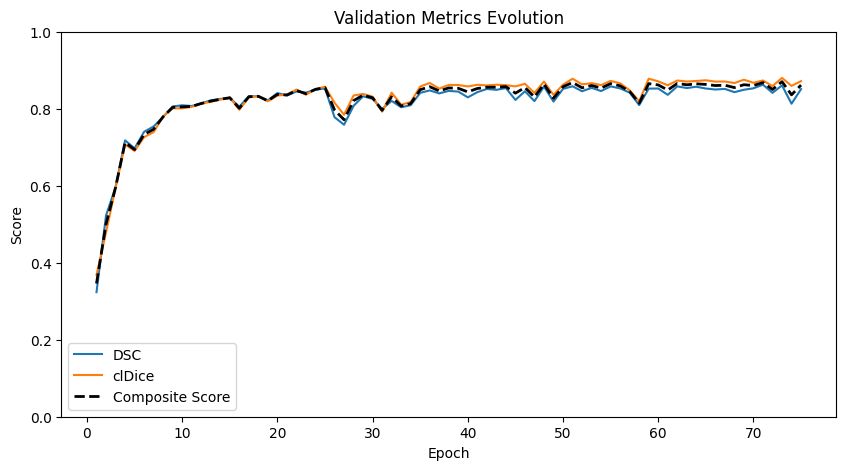

In [ ]:
import os
import torch
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
from skimage.morphology import skeletonize

# Define weighting preference
ALPHA = 0.5  # Weight for DSC (1-Alpha is weight for clDice)

def compute_cldice(pred, gt):
    """Calculates hard clDice on binary numpy arrays"""
    if np.sum(pred) == 0 or np.sum(gt) == 0: return 0.0
    s_pred = skeletonize(pred)
    s_gt = skeletonize(gt)
    tp = np.sum(s_pred * gt) / (np.sum(s_pred) + 1e-5)
    ts = np.sum(s_gt * pred) / (np.sum(s_gt) + 1e-5)
    return (2 * tp * ts) / (tp + ts + 1e-5)

def compute_dsc(pred, gt):
    smooth = 1e-5
    return (2. * np.sum(pred * gt) + smooth) / (np.sum(pred) + np.sum(gt) + smooth)

# Main Selection Loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Gather all checkpoint files from the project directory
model_files = sorted(glob.glob(os.path.join(checkpoint_dir, "model_epoch_*.pt")))
model_files.sort(key=lambda x: int(x.split('_')[-1].replace('.pt', '')))

results = []

print(f"Evaluating {len(model_files)} checkpoints...")

# Iterate through checkpoints
for model_path in tqdm(model_files):
    epoch_num = int(model_path.split('_')[-1].replace('.pt', ''))

    # Load Model Architecture
    model = UNet(in_channels, out_channels, init_filters, depth).to(device)

    # Set weights_only=False to allow loading the metadata saved in the checkpoints
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    # Extract 'model_state_dict'
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.eval()

    dsc_scores = []
    cldice_scores = []

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            # Inference
            output = model(images)
            pred_prob = torch.sigmoid(output).cpu().numpy()
            pred_bin = (pred_prob > 0.5).astype(np.uint8)

            # Ground truth from DataLoader
            gt = masks.cpu().numpy().astype(np.uint8)

            for i in range(pred_bin.shape[0]):
                d = compute_dsc(pred_bin[i, 0], gt[i, 0])
                c = compute_cldice(pred_bin[i, 0], gt[i, 0])

                dsc_scores.append(d)
                cldice_scores.append(c)

    # Aggregate for this epoch
    avg_dsc = np.mean(dsc_scores)
    avg_cldice = np.mean(cldice_scores)
    fitness = (ALPHA * avg_dsc) + ((1 - ALPHA) * avg_cldice)

    results.append({
        'Epoch': epoch_num,
        'DSC': avg_dsc,
        'clDice': avg_cldice,
        'Fitness': fitness,
        'Path': model_path
    })

# Select Winner Epoch
df = pd.DataFrame(results)
best_row = df.loc[df['Fitness'].idxmax()]

print("\n" + "="*30)
print(f"MODEL WITH BEST COMPOSITE SCORE: Epoch {int(best_row['Epoch'])}")
print(f"Fitness Score: {best_row['Fitness']:.4f}")
print(f"DSC: {best_row['DSC']:.4f}")
print(f"clDice: {best_row['clDice']:.4f}")
print("="*30)

# Plotting metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(df['Epoch'], df['DSC'], label='DSC')
plt.plot(df['Epoch'], df['clDice'], label='clDice')
plt.plot(df['Epoch'], df['Fitness'], label='Composite Score', linestyle='--', linewidth=2, color='black')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()
plt.title('Validation Metrics Evolution')
plt.show()

In [ ]:
# Define the epoch to save: defaulting to the model with best 'fitness'
selected_epoch = int(best_row['Epoch'])

# Construct the path to the model checkpoint for the selected epoch
selected_model_filename = f"model_epoch_{selected_epoch}.pt"
selected_model_path = os.path.join(checkpoint_dir, selected_model_filename)

# Check if the selected model path exists
if not os.path.exists(selected_model_path):
    print(f"Warning: Model for epoch {selected_epoch} not found at {selected_model_path}. Saving the best fitness model instead.")
    # Fallback to saving the best fitness model if the selected epoch model doesn't exist
    selected_model_path = best_row['Path']
    selected_epoch = int(best_row['Epoch'])

# Save the chosen model state dictionary as 'best_model.pt'
best_model_path = os.path.join(checkpoint_dir, "best_model.pt")
shutil.copy2(selected_model_path, best_model_path)

print(f"Model from epoch {selected_epoch} saved as {best_model_path}")

Model from epoch 73 saved as /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/best_model.pt


# Model evaluation on VS (w/o any post-processing)

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# Show versioning of deep learning libraries
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

2.9.0+cu126 True


In [ ]:
# Paths
test_img_dir = os.path.join(data_dir, 'val', 'image')
test_mask_dir = os.path.join(data_dir, 'val', 'manual_py') # Path to ground truth masks

best_model_path = os.path.join(checkpoint_dir, "best_model.pt")
output_masks_dir = "/tmp/val-results" # path for temporarily saving output masks

## Load model and params

In [ ]:
import json
import torch

def load_model_from_checkpoint(checkpoint_dir):
    # Load parameters
    params_path = os.path.join(checkpoint_dir, "training_params.json")
    with open(params_path, 'r') as f:
        params = json.load(f)
    print(f"Loaded parameters: {params}")

    # Initialize model
    model = UNet(
        in_channels=params["in_channels"],
        out_channels=params["out_channels"],
        init_filters=params["init_filters"],
        depth=params["depth"]
    )

    # Find the best model
    checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")
    if not os.path.exists(checkpoint_path):
        # Fallback to the last saved epoch if best_model doesn't exist
        checkpoints = glob.glob(os.path.join(checkpoint_dir, "model_epoch_*.pt"))
        checkpoint_path = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.pt', '')))[-1]

    # Load model state
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # weights_only=False allows loading the custom dictionary saved during training
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Extract the state dict from the dictionary
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    print(f"Checkpoint loaded from {checkpoint_path}")
    return model, params

In [ ]:
# checkpoint_dir = os.path.join(...)  # checkpoint directory
# the epoch_number is not needed, since our system automatically saves the best model in the checkpoint directory

model, params = load_model_from_checkpoint(checkpoint_dir)
input_size = tuple(params["input_size"])

Loaded parameters: {'input_size': [512, 512], 'in_channels': 3, 'out_channels': 1, 'init_filters': 32, 'depth': 4, 'n_epochs': 75, 'batch_size': 8, 'learning_rate': 0.001, 'checkpoint_freq': 1}
Checkpoint loaded from /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/best_model.pt


## Apply model

In [ ]:
from torchvision import transforms
import torchvision.transforms.functional as F
import torch.nn.functional as F_nn
import skimage.morphology as morph
from PIL import ImageFilter

# Create output folders if not present
os.makedirs(output_masks_dir, exist_ok=True)

# Send model to device and set to eval
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Initialize Test Dataset and Loader
test_dataset = RVCdataset(test_img_dir, test_mask_dir, params['in_channels'], patch_size=None, mode='val')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

# Inference Loop
model.eval()
with torch.no_grad():
    for i, (image, mask) in enumerate(tqdm(test_loader, desc="Generating Predictions")):
        image = image.to(device)
        output = model(image)

        # Handle potential size mismatches (if the model architecture requires specific multiples)
        original_size = (mask.shape[2], mask.shape[3]) # (H, W)
        if output.shape[-2:] != original_size:
            output = F_nn.interpolate(output, size=original_size, mode='bilinear', align_corners=False)

        # Binarize
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
        pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)

        # Save results
        img_name = test_dataset.image_list[i]
        pred_mask_img = Image.fromarray(pred_mask_bin * 255)
        pred_mask_img.save(os.path.join(output_masks_dir, img_name))

        prob_filename = img_name.rsplit('.', 1)[0] + '.npy'
        np.save(os.path.join(output_masks_dir, prob_filename), pred_mask)

Generating Predictions: 100%|██████████| 60/60 [00:30<00:00,  1.97it/s]


## Compute metrics

### Functions

In [ ]:
import numpy as np
import torch
import pandas as pd
from skimage.morphology import skeletonize, remove_small_objects
from skimage.measure import label, regionprops
from scipy.spatial.distance import cdist
from scipy.ndimage import distance_transform_edt
from sklearn.metrics import matthews_corrcoef, average_precision_score, confusion_matrix
from medpy.metric.binary import hd95
from skan import Skeleton, summarize
import warnings

# Suppress skan warnings for cleaner output
warnings.filterwarnings("ignore")

class ChallengeMetrics:
    def __init__(self):
        pass

    def compute_dsc(self, pred, gt):
        """
        Dice Similarity Coefficient (DSC) as defined in Eq (1).
        DSC = 2 * |X n Y| / (|X| + |Y|)
        """
        smooth = 1e-5
        intersection = np.sum(pred * gt)
        return (2. * intersection + smooth) / (np.sum(pred) + np.sum(gt) + smooth)

    def compute_cldice(self, pred, gt):
        """
        Centerline Dice (clDice) as defined in Eq (2).
        clDice = 2 * TP * TS / (TP + TS)
        """
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return 0.0

        # Skeletonize masks (expects boolean, returns boolean)
        s_pred = skeletonize(pred > 0)
        s_gt = skeletonize(gt > 0)

        # Topological Precision (TP): Fraction of predicted skeleton in GT mask
        # Eq: |Sy n X| / |Sy|
        tp = np.sum(s_pred * gt) / (np.sum(s_pred) + 1e-5)

        # Topological Sensitivity (TS): Fraction of GT skeleton in Predicted mask
        # Eq: |Sx n Y| / |Sx|
        ts = np.sum(s_gt * pred) / (np.sum(s_gt) + 1e-5)

        # Harmonic Mean
        cldice = (2 * tp * ts) / (tp + ts + 1e-5)
        return cldice

    def compute_mcc(self, pred, gt):
        """Matthews Correlation Coefficient"""
        # Flatten arrays
        p_flat = pred.flatten()
        g_flat = gt.flatten()
        return matthews_corrcoef(g_flat, p_flat)

    def compute_auprc(self, probs, gt):
        """Area Under Precision-Recall Curve (Requires probabilities)"""
        p_flat = probs.flatten()
        g_flat = gt.flatten()
        return average_precision_score(g_flat, p_flat)

    def compute_hd95(self, pred, gt):
        """95th Percentile Hausdorff Distance"""
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return np.nan
        # medpy expects boolean arrays
        return hd95(pred > 0, gt > 0)

    def analyze_morphology(self, pred, mask_shape):
        """
        Computes Skeleton/Graph metrics:
        NT (Trees), VD (Density), NB (Branches), MR (Mean Radius)
        Tortuosity: DM (Distance Metric), SOAM (Sum of Angles), ICM (Inflection Count)
        """
        stats = {}

        # Vascular Density (VD)
        stats['VD'] = np.sum(pred) / (mask_shape[0] * mask_shape[1])

        if np.sum(pred) == 0:
            return {k: 0 for k in ['NT', 'VD', 'NB', 'MR', 'DM', 'ICM', 'SOAM']}

        # Skeletonize for Graph Analysis
        skel = skeletonize(pred > 0)

        # Number of Vascular Trees (NT) - Connected Components
        labeled_skel, num_trees = label(skel, return_num=True, connectivity=2)
        stats['NT'] = num_trees

        # Mean Radius (MR)
        dist_map = distance_transform_edt(pred)
        radii = dist_map[skel]
        stats['MR'] = np.mean(radii) if len(radii) > 0 else 0

        # Branch & Tortuosity Analysis using Skan
        try:
            skel_obj = Skeleton(skel)
            branch_data = summarize(skel_obj)

            # Number of Branches (NB)
            stats['NB'] = len(branch_data)

            # Distance Metric (DM) = Path Length / Euclidean Distance
            # Ideally close to 1 for straight lines. Higher = more tortuous.
            stats['DM'] = np.mean(branch_data['branch-distance'] / (branch_data['euclidean-distance'] + 1e-5))

            # SOAM (Sum of Angles Metric) and ICM (Inflection Count Metric)
            # We approximate these by iterating through branch coordinates provided by Skan
            total_soam = 0
            total_icm = 0

            for i, branch_idx in enumerate(branch_data.index):
                coords = skel_obj.path_coordinates(i)
                if len(coords) > 2:
                    # Vectors between sequential points
                    vectors = np.diff(coords, axis=0)
                    # Normalize vectors
                    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
                    vectors_norm = vectors / (norms + 1e-10)

                    # Dot product of consecutive vectors to get cosine of angle
                    # Clip to [-1, 1] to avoid numerical errors
                    dot_products = np.sum(vectors_norm[:-1] * vectors_norm[1:], axis=1)
                    dot_products = np.clip(dot_products, -1.0, 1.0)

                    # Angles in radians
                    angles = np.arccos(dot_products)

                    # SOAM: Sum of angles for this branch
                    total_soam += np.sum(angles)

                    # ICM: Inflection points (change in sign of cross product 2D)
                    # We use the cross product of consecutive vectors (z-component)
                    cross_products = np.cross(vectors[:-1], vectors[1:])
                    # Sign changes in cross product indicate inflection
                    signs = np.sign(cross_products)
                    inflections = np.sum(np.abs(np.diff(signs)) > 0)
                    total_icm += inflections

            # Average per branch
            stats['SOAM'] = total_soam / (stats['NB'] + 1e-5)
            stats['ICM'] = total_icm / (stats['NB'] + 1e-5)

        except Exception as e:
            # Fallback if skeleton analysis fails (e.g. no branches)
            # print(f"Graph analysis error: {e}")
            stats['NB'] = 0
            stats['DM'] = 1.0
            stats['SOAM'] = 0
            stats['ICM'] = 0

        return stats

    def compute_all_stats(self, pred, gt):
        """
        Computes the fundamental metrics requested using formulas from the review paper.
        """
        p_flat = (pred > 0).flatten()
        g_flat = (gt > 0).flatten()

        tn, fp, fn, tp = confusion_matrix(g_flat, p_flat).ravel()

        # Avoid division by zero
        smooth = 1e-7

        sen = tp / (tp + fn + smooth)
        spe = tn / (tn + fp + smooth)
        pre = tp / (tp + fp + smooth)
        acc = (tp + tn) / (tp + tn + fp + fn + smooth)

        # Jaccard Similarity: Intersection over Union
        intersection = np.logical_and(pred, gt).sum()
        union = np.logical_or(pred, gt).sum()
        js = (intersection + smooth) / (union + smooth)

        # G-mean and FPR
        gmean = np.sqrt(sen * spe)
        fpr = fp / (tn + fp + smooth)

        return {
            'Sensitivity': sen,
            'Specificity': spe,
            'Precision': pre,
            'Accuracy': acc,
            'Jaccard': js,
            'G-mean': gmean,
            'FPR': fpr
        }

### Comparison

In [ ]:
# Initialize
metrics = ChallengeMetrics()
results_list = []

# Get list of saved predictions, assuming filenames in output_masks_dir match those in test_mask_dir
pred_files = sorted([f for f in os.listdir(output_masks_dir) if f.endswith('.png')])

print(f"Found {len(pred_files)} saved masks for evaluation.")

for filename in tqdm(pred_files, desc="Computing Metrics"):
    # Load Paths
    pred_path = os.path.join(output_masks_dir, filename)
    gt_path = os.path.join(test_mask_dir, filename)

    # Check if GT exists
    if not os.path.exists(gt_path):
        print(f"Warning: Ground truth not found for {filename}. Skipping.")
        continue

    prob_path = os.path.join(output_masks_dir, filename.rsplit('.', 1)[0] + '.npy')
    if os.path.exists(prob_path):
        pred_prob = np.load(prob_path)
    else:
        print(f"Warning: Probability map not found for {filename}. Skipping.")
        pred_prob = None
        continue

    # Load masks, convert to grayscale ('L'), and normalize to 0-1 binary
    pred_img = np.array(Image.open(pred_path).convert('L'))
    gt_img = np.array(Image.open(gt_path).convert('L'))

    # Binarize
    pred_bin = (pred_img > 0).astype(np.uint8)
    gt_bin = (gt_img > 0).astype(np.uint8)

    # Compute Metrics
    dsc = metrics.compute_dsc(pred_bin, gt_bin)
    mcc = metrics.compute_mcc(pred_bin, gt_bin)
    hd95_val = metrics.compute_hd95(pred_bin, gt_bin)
    if pred_prob is not None:
        auprc = metrics.compute_auprc(pred_prob, gt_bin)

    # Topology
    cldice = metrics.compute_cldice(pred_bin, gt_bin)

    # Morphology (Skeleton analysis) - COMPUTED FOR BOTH PRED AND GT
    pred_stats = metrics.analyze_morphology(pred_bin, pred_bin.shape)
    gt_stats = metrics.analyze_morphology(gt_bin, gt_bin.shape)

    # Store Results
    row = {
        'Filename': filename,
        'DSC': dsc,
        'clDice': cldice,
        'MCC': mcc,
        'HD95': hd95_val,
        'AUPRC': auprc if pred_prob is not None else 'NA',
    }

    base_stats = metrics.compute_all_stats(pred_bin, gt_bin)
    row.update(base_stats)

    # Add Prediction stats (prefixed with Pred_)
    for k, v in pred_stats.items():
        row[f'Pred_{k}'] = v

    # Add Ground Truth stats (prefixed with GT_)
    for k, v in gt_stats.items():
        row[f'GT_{k}'] = v

    results_list.append(row)

# Create DataFrame
df = pd.DataFrame(results_list)

# Save and Print Report
print("\n" + "="*60)
print("FINAL EVALUATION REPORT (on Saved Masks)")
print("="*60)

# Main Metrics
print(f"DSC:      {df['DSC'].mean():.4f} \u00B1 {df['DSC'].std():.4f}")
print(f"clDice:   {df['clDice'].mean():.4f} \u00B1 {df['clDice'].std():.4f}")
print("-----------------------------------------------------------")
# all other metrics
new_metrics = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Jaccard', 'MCC', 'G-mean', 'FPR', 'HD95', 'AUPRC']
for m in new_metrics:
    print(f"{m:15}: {df[m].mean():.4f} ± {df[m].std():.4f}")

print("\n--- Vascular Network Characterization (Pred vs GT) ---")

def print_comparison(name, key, unit=""):
    pred_mean = df[f'Pred_{key}'].mean()
    pred_std = df[f'Pred_{key}'].std()
    gt_mean = df[f'GT_{key}'].mean()
    gt_std = df[f'GT_{key}'].std()
    print(f"{name}:")
    print(f"   Pred: {pred_mean:.4f} ± {pred_std:.4f} {unit}")
    print(f"   GT:   {gt_mean:.4f} ± {gt_std:.4f} {unit}")
    # Show percentage error relative to GT
    if gt_mean != 0:
        err = ((pred_mean - gt_mean) / gt_mean) * 100
        print(f"   Diff: {pred_mean - gt_mean:.4f} {unit} ({err:+.2f}%)\n")
    else:
        print(f"   Diff: {pred_mean - gt_mean:.4f}\n")

print_comparison("Vascular Density (VD)", "VD")
print_comparison("Avg Vessel Radius (MR)", "MR", "px")
print_comparison("Avg Branch Count (NB)", "NB")
print_comparison("Tortuosity (DM)", "DM")
print_comparison("Tortuosity (SOAM)", "SOAM", "rads")
print_comparison("Tortuosity (ICM)", "ICM", "inflections")

# Save to CSV
results_csv_path = os.path.join(checkpoint_dir, 'validation_results.csv')
df.to_csv(results_csv_path, index=False)
print(f"\nDetailed results saved to: {results_csv_path}")

Found 60 saved masks for evaluation.


Computing Metrics: 100%|██████████| 60/60 [01:28<00:00,  1.47s/it]



FINAL EVALUATION REPORT (on Saved Masks)
DSC:      0.8606 ± 0.0533
clDice:   0.8801 ± 0.0540
-----------------------------------------------------------
Sensitivity    : 0.9011 ± 0.0590
Specificity    : 0.9857 ± 0.0030
Precision      : 0.8256 ± 0.0605
Accuracy       : 0.9800 ± 0.0043
Jaccard        : 0.7589 ± 0.0788
MCC            : 0.8513 ± 0.0535
G-mean         : 0.9419 ± 0.0312
FPR            : 0.0143 ± 0.0030
HD95           : 17.0571 ± 15.2383
AUPRC          : 0.9396 ± 0.0448

--- Vascular Network Characterization (Pred vs GT) ---
Vascular Density (VD):
   Pred: 0.0812 ± 0.0197 
   GT:   0.0747 ± 0.0181 
   Diff: 0.0065  (+8.69%)

Avg Vessel Radius (MR):
   Pred: 4.0094 ± 0.4140 px
   GT:   3.5177 ± 0.3448 px
   Diff: 0.4917 px (+13.98%)

Avg Branch Count (NB):
   Pred: 182.3667 ± 55.4366 
   GT:   185.7833 ± 57.0834 
   Diff: -3.4167  (-1.84%)

Tortuosity (DM):
   Pred: 459.5629 ± 1214.9542 
   GT:   1.0807 ± 0.0085 
   Diff: 458.4823  (+42426.45%)

Tortuosity (SOAM):
   Pred: 20

# Post-processing (discrimination threshold and post-processing sequences)

## Libraries and directories

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# Show versioning of deep learning libraries
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

2.9.0+cu126 True


In [ ]:
# Paths
test_img_dir = os.path.join(data_dir, 'train', 'image')
test_mask_dir = os.path.join(data_dir, 'train', 'manual_py')

best_model_path = os.path.join(checkpoint_dir, "best_model.pt")

train_prob_dir = os.path.join(data_dir, 'prob_maps', 'train')
val_prob_dir = os.path.join(data_dir, 'prob_maps', 'val')

## Load model and params

In [ ]:
import json
import torch

def load_model_from_checkpoint(checkpoint_dir):
    # Load parameters
    params_path = os.path.join(checkpoint_dir, "training_params.json")
    with open(params_path, 'r') as f:
        params = json.load(f)
    print(f"Loaded parameters: {params}")

    # Initialize model
    model = UNet(
        in_channels=params["in_channels"],
        out_channels=params["out_channels"],
        init_filters=params["init_filters"],
        depth=params["depth"]
    )

    # Find the best model
    checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")
    if not os.path.exists(checkpoint_path):
        # Fallback to the last saved epoch if best_model doesn't exist
        checkpoints = glob.glob(os.path.join(checkpoint_dir, "model_epoch_*.pt"))
        checkpoint_path = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.pt', '')))[-1]

    # Load model state
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # weights_only=False allows loading the custom dictionary saved during training
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Extract the state dict from the dictionary
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    print(f"Checkpoint loaded from {checkpoint_path}")
    return model, params

In [ ]:
# checkpoint_dir = os.path.join(...)  # checkpoint directory
# the epoch_number is not needed, since our system automatically saves the best model in the checkpoint directory

model, params = load_model_from_checkpoint(checkpoint_dir)
input_size = tuple(params["input_size"])

Loaded parameters: {'input_size': [512, 512], 'in_channels': 3, 'out_channels': 1, 'init_filters': 32, 'depth': 4, 'n_epochs': 75, 'batch_size': 8, 'learning_rate': 0.001, 'checkpoint_freq': 1}
Checkpoint loaded from /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/best_model.pt


## Apply model to obtain probability maps

In [ ]:
import os
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
import shutil

def generate_probability_maps(model, loader, device, output_dir):
    """
    Generates and saves raw probability maps as .npy files.
    Checks for existing files and validates count before processing.
    """

    # Clear directory if partial data exists
    if os.path.exists(output_dir):
        existing_files = [f for f in os.listdir(output_dir) if f.endswith('.npy')]
        if len(existing_files) > 0 and len(existing_files) != len(loader.dataset):
            print(f"Detected {len(existing_files)} existing maps, but dataset has {len(loader.dataset)}. Clearing '{output_dir}'...")
            shutil.rmtree(output_dir) # Remove the directory and its contents
            os.makedirs(output_dir) # Recreate an empty directory

    # Check for existing files (after potential clearing)
    if os.path.exists(output_dir):
        # Count only .npy files to avoid counting system files like .DS_Store
        existing_files = [f for f in os.listdir(output_dir) if f.endswith('.npy')]
        num_existing = len(existing_files)
        num_dataset = len(loader.dataset)

        if num_existing > 0:
            if num_existing != num_dataset:
                # This case should ideally not be reached after clearing, but as a safeguard.
                raise RuntimeError(
                    f"Integrity Error: Found {num_existing} probability maps in '{output_dir}', "
                    f"but the dataset contains {num_dataset} images. \n"
                    "Please manually clear the directory to regenerate or check your dataset split."
                )
            else:
                # MATCH: Files exist and count is correct. Skip generation.
                print(f"Probability maps already exist in '{output_dir}' ({num_existing} files). Skipping generation.")
                return

    # Proceed with Generation
    os.makedirs(output_dir, exist_ok=True)
    model.eval()

    with torch.no_grad():
        current_idx_in_dataset = 0 # To track the actual image index in the dataset
        for images, masks in tqdm(loader, desc=f"Generating Maps for {os.path.basename(output_dir)}"):
            images = images.to(device)

            # Inference
            outputs = model(images) # outputs will be (batch_size, 1, H, W)

            # Iterate over each item in the batch and save individually
            for i in range(outputs.shape[0]): # outputs.shape[0] is batch_size
                output_single = outputs[i:i+1] # Get one output (1, 1, H, W)
                mask_single = masks[i:i+1]     # Corresponding mask for size check (1, 1, H, W)

                # Interpolate if necessary (using mask_single for original_size)
                original_size = (mask_single.shape[2], mask_single.shape[3])
                if output_single.shape[-2:] != original_size:
                    output_single = torch.nn.functional.interpolate(output_single, size=original_size, mode='bilinear', align_corners=False)

                # Get Probabilities (0.0 to 1.0) - .squeeze() will now make it 2D
                prob_map = torch.sigmoid(output_single).cpu().squeeze().numpy() # This will be (H, W)

                # Save as numpy array for full float precision
                # Use current_idx_in_dataset to get correct filename from the dataset
                if hasattr(loader.dataset, 'image_list'):
                    filename = loader.dataset.image_list[current_idx_in_dataset]
                    name_no_ext = os.path.splitext(filename)[0]
                else:
                    name_no_ext = f"image_{current_idx_in_dataset}"

                np.save(os.path.join(output_dir, f"{name_no_ext}.npy"), prob_map)
                current_idx_in_dataset += 1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

train_dataset = RVCdataset(train_img_dir, train_mask_dir, in_channels, patch_size=None, mode='val')
val_dataset = RVCdataset(val_img_dir, val_mask_dir, in_channels, patch_size=None, mode='val')

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

# Run Generation for Train
print("Checking Training Probability Maps...")
generate_probability_maps(model, train_loader, device, train_prob_dir)

# Run Generation for Val
print("Checking Validation Probability Maps...")
generate_probability_maps(model, val_loader, device, val_prob_dir)

Checking Training Probability Maps...
Probability maps already exist in '/content/drive/MyDrive/MIP - project/data/prob_maps/train' (480 files). Skipping generation.
Checking Validation Probability Maps...
Probability maps already exist in '/content/drive/MyDrive/MIP - project/data/prob_maps/val' (60 files). Skipping generation.


## Metrics functions

In [ ]:
import numpy as np
import torch
import pandas as pd
from skimage.morphology import skeletonize, remove_small_objects
from skimage.measure import label, regionprops
from scipy.spatial.distance import cdist
from scipy.ndimage import distance_transform_edt
from sklearn.metrics import matthews_corrcoef, average_precision_score, confusion_matrix
from medpy.metric.binary import hd95
from skan import Skeleton, summarize
import warnings

# Suppress skan warnings for cleaner output
warnings.filterwarnings("ignore")

class ChallengeMetrics:
    def __init__(self):
        pass

    def compute_dsc(self, pred, gt):
        """
        Dice Similarity Coefficient (DSC) as defined in Eq (1).
        DSC = 2 * |X n Y| / (|X| + |Y|)
        """
        smooth = 1e-5
        intersection = np.sum(pred * gt)
        return (2. * intersection + smooth) / (np.sum(pred) + np.sum(gt) + smooth)

    def compute_cldice(self, pred, gt):
        """
        Centerline Dice (clDice) as defined in Eq (2).
        clDice = 2 * TP * TS / (TP + TS)
        """
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return 0.0

        # Skeletonize masks (expects boolean, returns boolean)
        s_pred = skeletonize(pred > 0)
        s_gt = skeletonize(gt > 0)

        # Topological Precision (TP): Fraction of predicted skeleton in GT mask
        # Eq: |Sy n X| / |Sy|
        tp = np.sum(s_pred * gt) / (np.sum(s_pred) + 1e-5)

        # Topological Sensitivity (TS): Fraction of GT skeleton in Predicted mask
        # Eq: |Sx n Y| / |Sx|
        ts = np.sum(s_gt * pred) / (np.sum(s_gt) + 1e-5)

        # Harmonic Mean
        cldice = (2 * tp * ts) / (tp + ts + 1e-5)
        return cldice

    def compute_mcc(self, pred, gt):
        """Matthews Correlation Coefficient"""
        # Flatten arrays
        p_flat = pred.flatten()
        g_flat = gt.flatten()
        return matthews_corrcoef(g_flat, p_flat)

    def compute_auprc(self, probs, gt):
        """Area Under Precision-Recall Curve (Requires probabilities)"""
        p_flat = probs.flatten()
        g_flat = gt.flatten()
        return average_precision_score(g_flat, p_flat)

    def compute_hd95(self, pred, gt):
        """95th Percentile Hausdorff Distance"""
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return np.nan
        # medpy expects boolean arrays
        return hd95(pred > 0, gt > 0)

    def analyze_morphology(self, pred, mask_shape):
        """
        Computes Skeleton/Graph metrics:
        NT (Trees), VD (Density), NB (Branches), MR (Mean Radius)
        Tortuosity: DM (Distance Metric), SOAM (Sum of Angles), ICM (Inflection Count)
        """
        stats = {}

        # Vascular Density (VD)
        stats['VD'] = np.sum(pred) / (mask_shape[0] * mask_shape[1])

        if np.sum(pred) == 0:
            return {k: 0 for k in ['NT', 'VD', 'NB', 'MR', 'DM', 'ICM', 'SOAM']}

        # Skeletonize for Graph Analysis
        skel = skeletonize(pred > 0)

        # Number of Vascular Trees (NT) - Connected Components
        labeled_skel, num_trees = label(skel, return_num=True, connectivity=2)
        stats['NT'] = num_trees

        # Mean Radius (MR)
        dist_map = distance_transform_edt(pred)
        radii = dist_map[skel]
        stats['MR'] = np.mean(radii) if len(radii) > 0 else 0

        # Branch & Tortuosity Analysis using Skan
        try:
            skel_obj = Skeleton(skel)
            branch_data = summarize(skel_obj)

            # Number of Branches (NB)
            stats['NB'] = len(branch_data)

            # Distance Metric (DM)
            # Ideally close to 1 for straight lines. Higher = more tortuous.
            # DM reported here is the average across all branches
            stats['DM'] = np.mean(branch_data['branch-distance'] / (branch_data['euclidean-distance'] + 1e-5))

            # SOAM (Sum of Angles Metric) and ICM (Inflection Count Metric)
            # We approximate these by iterating through branch coordinates provided by Skan
            total_soam = 0
            total_icm = 0

            for i, branch_idx in enumerate(branch_data.index):
                coords = skel_obj.path_coordinates(i)
                if len(coords) > 2:
                    # Vectors between sequential points
                    vectors = np.diff(coords, axis=0)
                    # Normalize vectors
                    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
                    vectors_norm = vectors / (norms + 1e-10)

                    # Dot product of consecutive vectors to get cosine of angle
                    # Clip to [-1, 1] to avoid numerical errors
                    dot_products = np.sum(vectors_norm[:-1] * vectors_norm[1:], axis=1)
                    dot_products = np.clip(dot_products, -1.0, 1.0)

                    # Angles in radians
                    angles = np.arccos(dot_products)

                    # SOAM: Sum of angles for this branch
                    total_soam += np.sum(angles)

                    # ICM: Inflection points (change in sign of cross product 2D)
                    # We use the cross product of consecutive vectors (z-component)
                    cross_products = np.cross(vectors[:-1], vectors[1:])
                    # Sign changes in cross product indicate inflection
                    signs = np.sign(cross_products)
                    inflections = np.sum(np.abs(np.diff(signs)) > 0)
                    total_icm += inflections

            # Average per branch
            stats['SOAM'] = total_soam / (stats['NB'] + 1e-5)
            stats['ICM'] = total_icm / (stats['NB'] + 1e-5)

        except Exception as e:
            # Fallback if skeleton analysis fails (e.g. no branches)
            # print(f"Graph analysis error: {e}")
            stats['NB'] = 0
            stats['DM'] = 1.0
            stats['SOAM'] = 0
            stats['ICM'] = 0

        return stats

    def compute_all_stats(self, pred, gt):
        """
        Computes the fundamental metrics requested using formulas from the review paper.
        """
        p_flat = (pred > 0).flatten()
        g_flat = (gt > 0).flatten()

        tn, fp, fn, tp = confusion_matrix(g_flat, p_flat).ravel()

        # Avoid division by zero
        smooth = 1e-7

        sen = tp / (tp + fn + smooth)
        spe = tn / (tn + fp + smooth)
        pre = tp / (tp + fp + smooth)
        acc = (tp + tn) / (tp + tn + fp + fn + smooth)

        # Jaccard Similarity: Intersection over Union
        intersection = np.logical_and(pred, gt).sum()
        union = np.logical_or(pred, gt).sum()
        js = (intersection + smooth) / (union + smooth)

        # G-mean and FPR
        gmean = np.sqrt(sen * spe)
        fpr = fp / (tn + fp + smooth)

        return {
            'Sensitivity': sen,
            'Specificity': spe,
            'Precision': pre,
            'Accuracy': acc,
            'Jaccard': js,
            'G-mean': gmean,
            'FPR': fpr
        }

## Find best threshold (value/method) for each sequence

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage import morphology
from skimage.filters import threshold_otsu
from skimage.morphology import disk

# Optimize discrimination threshold for every post-processing sequence
class SegmentOptimizer:
    def __init__(self, prob_dir, mask_dir, fitness_alpha=0.3):
        self.prob_dir = prob_dir
        self.mask_dir = mask_dir
        self.files = [f.replace('.npy', '') for f in os.listdir(prob_dir) if f.endswith('.npy')]
        self.alpha = fitness_alpha # Weight for DSC (1-alpha for clDice)
        self.metrics_engine = ChallengeMetrics()

        # Load Data into RAM for speed
        print("Loading data into memory...")
        self.data = []
        for f in self.files:
            prob = np.load(os.path.join(prob_dir, f"{f}.npy"))
            # Load GT mask
            mask_path = os.path.join(mask_dir, f"{f}.png")
            gt = np.array(Image.open(mask_path).convert('L'))
            gt = (gt > 0).astype(np.uint8)
            self.data.append({'name': f, 'prob': prob, 'gt': gt})

    def apply_sequence(self, mask, seq_name):
        """Applies the specific morphological sequence."""
        selem = disk(1)
        min_obj_size = 30
        hole_area = 30

        m = mask.astype(bool)

        if seq_name == 'Baseline':
            return m
        elif seq_name == 'Erosion':
            return morphology.binary_erosion(m, selem)
        elif seq_name == 'Dilation':
            return morphology.binary_dilation(m, selem)
        elif seq_name == 'Closing':
            return morphology.binary_closing(m, selem)
        elif seq_name == 'Opening':
            return morphology.binary_opening(m, selem)
        elif seq_name == 'RSO':
            return morphology.remove_small_objects(m, min_size=min_obj_size)
        elif seq_name == 'FSH':
            return morphology.remove_small_holes(m, area_threshold=hole_area)
        elif seq_name == 'FSH -> RSO -> Closing':
            m = morphology.remove_small_holes(m, area_threshold=hole_area)
            m = morphology.remove_small_objects(m, min_size=min_obj_size)
            return morphology.binary_closing(m, selem)
        elif seq_name == 'RSO -> Opening -> Erosion':
            m = morphology.remove_small_objects(m, min_size=min_obj_size)
            m = morphology.binary_opening(m, selem)
            return morphology.binary_erosion(m, selem)
        elif seq_name == 'RSO -> Closing':
            m = morphology.remove_small_objects(m, min_size=min_obj_size)
            return morphology.binary_closing(m, selem)
        elif seq_name == 'Opening -> FSH -> RSO':
            m = morphology.binary_opening(m, selem)
            m = morphology.remove_small_holes(m, area_threshold=hole_area)
            return morphology.remove_small_objects(m, min_size=min_obj_size)
        return m

    def evaluate_batch(self, threshold_val, seq_name, use_otsu=False):
        """Calculates mean metrics for a specific configuration across all training images."""
        dsc_scores = []
        cldice_scores = []

        for item in self.data:
            prob = item['prob']
            gt = item['gt']

            if use_otsu:
                try:
                    thresh = threshold_otsu(prob)
                except:
                    thresh = 0.5
                binary = prob > thresh
            else:
                binary = prob > threshold_val

            processed = self.apply_sequence(binary, seq_name)
            processed_uint = processed.astype(np.uint8)

            d = self.metrics_engine.compute_dsc(processed_uint, gt)
            c = self.metrics_engine.compute_cldice(processed_uint, gt)

            dsc_scores.append(d)
            cldice_scores.append(c)

        mean_dsc = np.mean(dsc_scores)
        mean_cldice = np.mean(cldice_scores)
        fitness = (self.alpha * mean_dsc) + ((1 - self.alpha) * mean_cldice)

        return mean_dsc, mean_cldice, fitness

    def run_optimization(self):
        sequences = [
            'Baseline', 'Erosion', 'Dilation', 'Closing', 'Opening',
            'RSO', 'FSH', 'FSH -> RSO -> Closing',
            'RSO -> Opening -> Erosion', 'RSO -> Closing',
            'Opening -> FSH -> RSO'
        ]

        thresholds = np.arange(0.1, 0.95, 0.05)
        results = []
        history_data = {} # Dictionary to store curves for plotting

        print(f"Optimizing {len(sequences)} sequences...")

        for seq in tqdm(sequences, desc="Sequences"):
            # Storage for this sequence's curve
            seq_thresholds = []
            seq_dsc = []
            seq_cldice = []

            # Find Best Fixed Threshold
            best_fixed_fitness = -1
            best_fixed_t = 0
            best_fixed_metrics = (0, 0)

            for t in tqdm(thresholds, desc=f"  Thresholds for {seq}", leave=False):
                dsc, cld, fit = self.evaluate_batch(t, seq, use_otsu=False)

                # Store history
                seq_thresholds.append(t)
                seq_dsc.append(dsc)
                seq_cldice.append(cld)

                if fit > best_fixed_fitness:
                    best_fixed_fitness = fit
                    best_fixed_t = t
                    best_fixed_metrics = (dsc, cld)

            # Store the full history for this sequence
            history_data[seq] = {
                'thresholds': seq_thresholds,
                'DSC': seq_dsc,
                'clDice': seq_cldice
            }

            # Evaluate Otsu (just for the winner table)
            otsu_dsc, otsu_cld, otsu_fit = self.evaluate_batch(None, seq, use_otsu=True)

            # Compare Otsu and Fixed Threshold to to select the winner
            if otsu_fit > best_fixed_fitness:
                winner_method = 'Otsu'
                winner_param = 'Dynamic'
                winner_metrics = (otsu_dsc, otsu_cld, otsu_fit)
            else:
                winner_method = 'Fixed'
                winner_param = best_fixed_t
                winner_metrics = (best_fixed_metrics[0], best_fixed_metrics[1], best_fixed_fitness)

            results.append({
                'Sequence': seq,
                'Method': winner_method,
                'Parameter': winner_param,
                'DSC': winner_metrics[0],
                'clDice': winner_metrics[1],
                'Fitness': winner_metrics[2]
            })

        return pd.DataFrame(results).sort_values(by='Fitness', ascending=False), history_data

def plot_threshold_curves(history_data):
    """
    Plots DSC and clDice vs Threshold for each sequence in subplots.
    """
    sequences = list(history_data.keys())
    num_seq = len(sequences)
    cols = 3
    rows = (num_seq + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i, seq in enumerate(sequences):
        ax = axes[i]
        data = history_data[seq]

        # Plot DSC
        ax.plot(data['thresholds'], data['DSC'], 'b-o', label='DSC', linewidth=2, markersize=4)
        # Plot clDice
        ax.plot(data['thresholds'], data['clDice'], 'r-s', label='clDice', linewidth=2, markersize=4)

        ax.set_title(seq, fontsize=12, fontweight='bold')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.0)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    # Turn off empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Loading data into memory...
Optimizing 11 sequences...


Sequences: 100%|██████████| 11/11 [4:22:13<00:00, 1430.31s/it]



--- Optimization Results on Training Set ---
                     Sequence Method  Parameter       DSC    clDice   Fitness
4                     Opening  Fixed       0.75  0.877046  0.897360  0.891266
10      Opening -> FSH -> RSO  Fixed       0.75  0.877115  0.897096  0.891102
9              RSO -> Closing  Fixed       0.80  0.878799  0.895676  0.890613
7       FSH -> RSO -> Closing  Fixed       0.80  0.878801  0.895644  0.890591
5                         RSO  Fixed       0.80  0.878872  0.895448  0.890475
3                     Closing  Fixed       0.85  0.878378  0.893677  0.889088
6                         FSH  Fixed       0.85  0.878419  0.893555  0.889014
0                    Baseline  Fixed       0.85  0.878409  0.893485  0.888962
2                    Dilation  Fixed       0.90  0.831734  0.900215  0.879671
8   RSO -> Opening -> Erosion  Fixed       0.10  0.855814  0.885236  0.876410
1                     Erosion  Fixed       0.10  0.855721  0.884570  0.875915


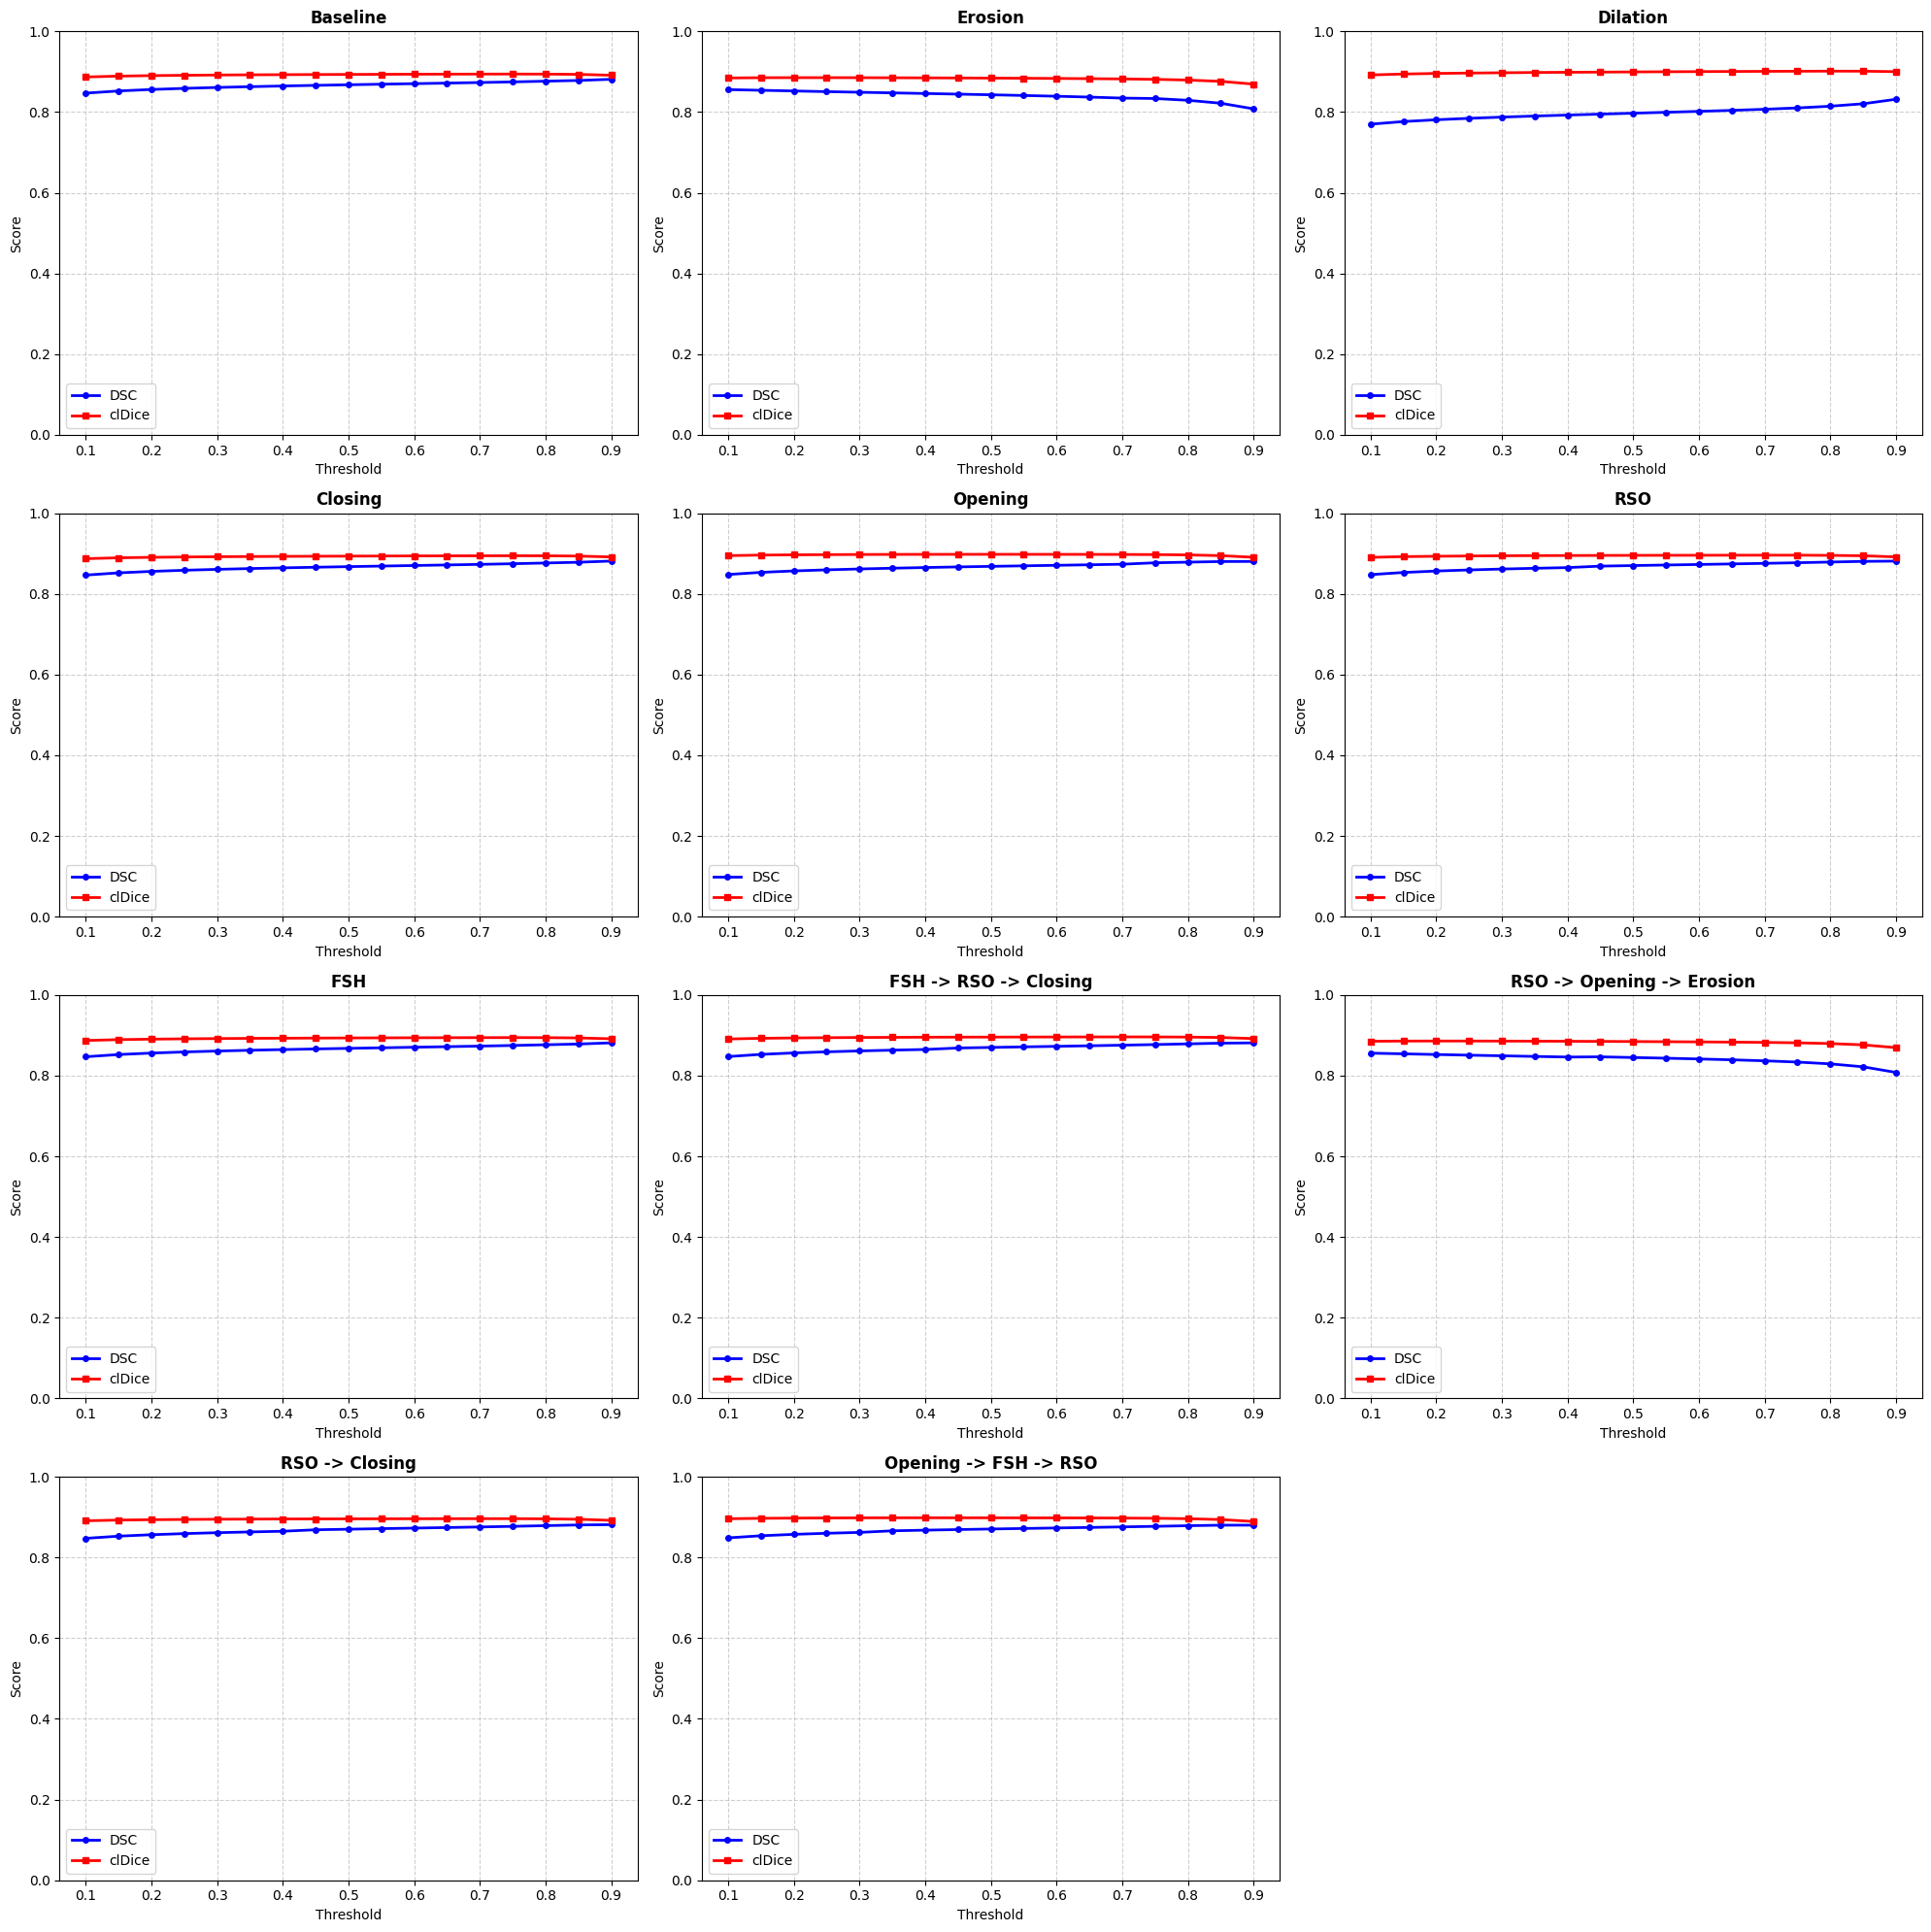

In [ ]:
optimizer = SegmentOptimizer(train_prob_dir, train_mask_dir)
train_results_df, history_data = optimizer.run_optimization()

print("\n--- Optimization Results on Training Set ---")
print(train_results_df)

# Generate the plots
plot_threshold_curves(history_data)

# Save results
save_dir = os.path.join(project_dir, '5 - Post-processing steps')
os.makedirs(save_dir, exist_ok=True)
csv_path = os.path.join(save_dir, 'train_optimization_results.csv')
train_results_df.to_csv(csv_path, index=False)

## Compute metrics for all sequences (with optimized threshold)

In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from PIL import Image
from skimage.filters import threshold_otsu

# Analysis of metrics on the different sequences to, then, select the best one
class Validator:
    def __init__(self, prob_dir, mask_dir, config_df):
        self.prob_dir = prob_dir
        self.mask_dir = mask_dir
        self.config_df = config_df
        self.files = [f.replace('.npy', '') for f in os.listdir(prob_dir) if f.endswith('.npy')]
        self.metrics_engine = ChallengeMetrics() # Uses the class defined previously
        self.optimizer_ref = SegmentOptimizer(prob_dir, mask_dir) # Reuse helper methods like apply_sequence
        self.optimizer_ref.data = [] # Clear data to save memory

    def run_validation(self):
        val_results = []

        # Explicitly define the skeleton metrics we want to track
        skeleton_keys = ['VD', 'NT', 'NB', 'MR', 'DM', 'SOAM', 'ICM']

        print(f"Evaluating {len(self.config_df)} optimized configurations on Validation Set...")

        # OPTIMIZATION: Pre-calculate GT Morphology, since it doesn't change
        # between configurations, allowing to save time
        print("Pre-calculating Ground Truth morphology metrics...")
        gt_morph_cache = {}

        for f in tqdm(self.files, desc="Caching GT Metrics"):
            mask_path = os.path.join(self.mask_dir, f"{f}.png")
            gt = np.array(Image.open(mask_path).convert('L'))
            gt = (gt > 0).astype(np.uint8)
            # Store the dictionary of morphology results for this file
            gt_morph_cache[f] = self.metrics_engine.analyze_morphology(gt, gt.shape)

        # Iterate over the optimized configurations (sequences + their best threshold method)
        for _, row in tqdm(self.config_df.iterrows(), total=len(self.config_df), desc="Validating Configurations"):
            seq = row['Sequence']
            method = row['Method']
            param = row['Parameter']

            # Temporary lists to store metrics for all images for THIS configuration
            batch_metrics = {
                'DSC': [], 'clDice': [], 'MCC': [], 'HD95': [], 'AUPRC': [],
                # Standard Statistics (Sens, Spec, etc.)
                'Sensitivity': [], 'Specificity': [], 'Precision': [],
                'Accuracy': [], 'Jaccard': [], 'G-mean': [], 'FPR': [],
                # Skeleton / Morphology Metrics (Prediction)
                'VD': [], 'NT': [], 'NB': [], 'MR': [], 'DM': [], 'SOAM': [], 'ICM': []
            }

            # Additional lists for GT and Diff metrics
            batch_gt_metrics = {k: [] for k in skeleton_keys}
            batch_diff_metrics = {k: [] for k in skeleton_keys}

            for f in self.files:
                # Load Val Prob
                prob = np.load(os.path.join(self.prob_dir, f"{f}.npy"))

                # Load Val GT
                mask_path = os.path.join(self.mask_dir, f"{f}.png")
                gt = np.array(Image.open(mask_path).convert('L'))
                gt = (gt > 0).astype(np.uint8)

                # Apply Thresholding Strategy
                if method == 'Otsu':
                    try:
                        thresh = threshold_otsu(prob)
                    except:
                        thresh = 0.5
                    binary = prob > thresh
                else:
                    binary = prob > float(param)

                # Apply Post-processing Sequence
                processed = self.optimizer_ref.apply_sequence(binary, seq)
                processed_uint = processed.astype(np.uint8)

                # COMPUTE ALL METRICS
                batch_metrics['DSC'].append(self.metrics_engine.compute_dsc(processed_uint, gt))
                batch_metrics['clDice'].append(self.metrics_engine.compute_cldice(processed_uint, gt))
                batch_metrics['MCC'].append(self.metrics_engine.compute_mcc(processed_uint, gt))
                batch_metrics['HD95'].append(self.metrics_engine.compute_hd95(processed_uint, gt))

                # Standard Statistics (Sens, Spec, etc.)
                stats = self.metrics_engine.compute_all_stats(processed_uint, gt)
                for key, value in stats.items():
                    if key in batch_metrics:
                        batch_metrics[key].append(value)


                # Skeleton / Morphology Metrics
                morph_stats_pred = self.metrics_engine.analyze_morphology(processed_uint, processed_uint.shape)

                # Retrieve GT
                morph_stats_gt = gt_morph_cache[f]

                for key in skeleton_keys:
                    # Save Prediction Metric
                    pred_val = morph_stats_pred.get(key, np.nan)
                    if key in batch_metrics:
                        batch_metrics[key].append(pred_val)

                    # Save GT Metric
                    gt_val = morph_stats_gt.get(key, np.nan)
                    batch_gt_metrics[key].append(gt_val)

                    # Save Difference (Pred - GT)
                    if not np.isnan(pred_val) and not np.isnan(gt_val):
                        batch_diff_metrics[key].append(pred_val - gt_val)
                    else:
                        batch_diff_metrics[key].append(np.nan)

            # Aggregate Results for this Configuration
            config_result = {
                'Sequence': seq,
                'Method': method,
                'Parameter': param
            }

            # Calculate Mean and Std for Prediction metrics
            for metric_name, values in batch_metrics.items():
                valid_values = [v for v in values if not np.isnan(v)]
                if metric_name == 'AUPRC':
                    config_result[metric_name] = self.metrics_engine.compute_auprc(prob, gt)
                elif valid_values:
                    config_result[f'Mean_{metric_name}'] = np.mean(valid_values)
                    config_result[f'Std_{metric_name}'] = np.std(valid_values)
                else:
                    config_result[f'Mean_{metric_name}'] = 0
                    config_result[f'Std_{metric_name}'] = 0

            # Calculate Mean and Std for GT and Differences
            for key in skeleton_keys:
                # GT Stats
                gt_vals = [v for v in batch_gt_metrics[key] if not np.isnan(v)]
                if gt_vals:
                    config_result[f'Mean_GT_{key}'] = np.mean(gt_vals)
                    config_result[f'Std_GT_{key}'] = np.std(gt_vals)
                else:
                    config_result[f'Mean_GT_{key}'] = 0
                    config_result[f'Std_GT_{key}'] = 0

                # Diff Stats
                diff_vals = [v for v in batch_diff_metrics[key] if not np.isnan(v)]
                if diff_vals:
                    config_result[f'Mean_Diff_{key}'] = np.mean(diff_vals)
                    config_result[f'Std_Diff_{key}'] = np.std(diff_vals)
                else:
                    config_result[f'Mean_Diff_{key}'] = 0
                    config_result[f'Std_Diff_{key}'] = 0

            val_results.append(config_result)

        return pd.DataFrame(val_results)


# Define the path where train_results_df was saved
save_dir_for_train_results = os.path.join(project_dir, '5 - Post-processing steps')
csv_path_for_train_results = os.path.join(save_dir_for_train_results, 'train_optimization_results.csv')

# Load train_results_df from the CSV file
train_results_df = pd.read_csv(csv_path_for_train_results)

# Initialize Validator with the Training Results DataFrame (which contains the configs to test)
validator = Validator(val_prob_dir, val_mask_dir, train_results_df)

# Run full validation
final_metrics_df = validator.run_validation()

# Save and Display Results
output_csv_path = os.path.join(project_dir, '5 - Post-processing steps', 'global_threshold_optimization_results.csv')
final_metrics_df.to_csv(output_csv_path, index=False)

print(f"\n")
print(f"\nFull validation results saved to: {output_csv_path}")

Loading data into memory...
Evaluating 11 optimized configurations on Validation Set...
Pre-calculating Ground Truth morphology metrics...


Validating Configurations: 100%|██████████| 11/11 [09:14<00:00, 50.44s/it]





Full validation results saved to: /content/drive/MyDrive/MIP - project/5 - Post-processing steps/global_threshold_optimization_results.csv


# Model evaluation on TS (with post-processing)

## Libraries and directories

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
# Show versioning of deep learning libraries
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

2.9.0+cu126 True


In [ ]:
# Paths
test_img_dir = os.path.join(data_dir, 'test', 'image')
test_mask_dir = os.path.join(data_dir, 'test', 'manual_py')

best_model_path = os.path.join(checkpoint_dir, "best_model.pt")
output_masks_dir = "/tmp/test-results" # path for temporarily saving output masks

## Load model and params

In [ ]:
import json
import torch

def load_model_from_checkpoint(checkpoint_dir):
    # Load parameters
    params_path = os.path.join(checkpoint_dir, "training_params.json")
    with open(params_path, 'r') as f:
        params = json.load(f)
    print(f"Loaded parameters: {params}")

    # Initialize model
    model = UNet(
        in_channels=params["in_channels"],
        out_channels=params["out_channels"],
        init_filters=params["init_filters"],
        depth=params["depth"]
    )

    # Find the best model
    checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")
    if not os.path.exists(checkpoint_path):
        # Fallback to the last saved epoch if best_model doesn't exist
        checkpoints = glob.glob(os.path.join(checkpoint_dir, "model_epoch_*.pt"))
        checkpoint_path = sorted(checkpoints, key=lambda x: int(x.split('_')[-1].replace('.pt', '')))[-1]

    # Load model state
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # weights_only=False allows loading the custom dictionary saved during training
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # Extract the state dict from the dictionary
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    print(f"Checkpoint loaded from {checkpoint_path}")
    return model, params

In [ ]:
# checkpoint_dir = os.path.join(...)  # checkpoint directory
# the epoch_number is not needed, since our system automatically saves the best model in the checkpoint directory

model, params = load_model_from_checkpoint(checkpoint_dir)
input_size = tuple(params["input_size"])

Loaded parameters: {'input_size': [512, 512], 'in_channels': 3, 'out_channels': 1, 'init_filters': 32, 'depth': 4, 'n_epochs': 75, 'batch_size': 8, 'learning_rate': 0.001, 'checkpoint_freq': 1}
Checkpoint loaded from /content/drive/MyDrive/MIP - project/DiceBCE_SRL-checkpoints/best_model.pt


## Apply model (with post-processing)

In [ ]:
from torchvision import transforms
import torchvision.transforms.functional as F
import torch.nn.functional as F_nn
import skimage.morphology as morph
from PIL import ImageFilter

# Create output folders if not present
os.makedirs(output_masks_dir, exist_ok=True)

# Send model to device and set to eval
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Initialize Test Dataset and Loader
test_dataset = RVCdataset(test_img_dir, test_mask_dir, params['in_channels'], patch_size=None, mode='test')
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

# Simplified Inference Loop
model.eval()
with torch.no_grad():
    for i, (image, mask) in enumerate(tqdm(test_loader, desc="Generating Predictions")):
        image = image.to(device)
        output = model(image)

        # Handle potential size mismatches (if the model architecture requires specific multiples)
        original_size = (mask.shape[2], mask.shape[3]) # (H, W)
        if output.shape[-2:] != original_size:
            output = F_nn.interpolate(output, size=original_size, mode='bilinear', align_corners=False)

        # Binarize mask
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
        pred_mask_bin = (pred_mask > 0.8).astype(np.uint8)

        # Apply post-processing
        pred_mask_bin = morph.remove_small_objects(pred_mask_bin, min_size=30)
        pred_mask_bin = morph.closing(pred_mask_bin, morph.disk(1))

        # Save results
        img_name = test_dataset.image_list[i]
        pred_mask_img = Image.fromarray(pred_mask_bin * 255)
        pred_mask_img.save(os.path.join(output_masks_dir, img_name))

        prob_filename = img_name.rsplit('.', 1)[0] + '.npy'
        np.save(os.path.join(output_masks_dir, prob_filename), pred_mask)

Generating Predictions: 100%|██████████| 60/60 [00:30<00:00,  1.99it/s]


## Compute metrics

### Functions

In [ ]:
import numpy as np
import torch
import pandas as pd
from skimage.morphology import skeletonize, remove_small_objects
from skimage.measure import label, regionprops
from scipy.spatial.distance import cdist
from scipy.ndimage import distance_transform_edt
from sklearn.metrics import matthews_corrcoef, average_precision_score, confusion_matrix
from medpy.metric.binary import hd95
from skan import Skeleton, summarize
import warnings

# Suppress skan warnings for cleaner output
warnings.filterwarnings("ignore")

class ChallengeMetrics:
    def __init__(self):
        pass

    def compute_dsc(self, pred, gt):
        """
        Dice Similarity Coefficient (DSC) as defined in Eq (1).
        DSC = 2 * |X n Y| / (|X| + |Y|)
        """
        smooth = 1e-5
        intersection = np.sum(pred * gt)
        return (2. * intersection + smooth) / (np.sum(pred) + np.sum(gt) + smooth)

    def compute_cldice(self, pred, gt):
        """
        Centerline Dice (clDice) as defined in Eq (2).
        clDice = 2 * TP * TS / (TP + TS)
        """
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return 0.0

        # Skeletonize masks (expects boolean, returns boolean)
        s_pred = skeletonize(pred > 0)
        s_gt = skeletonize(gt > 0)

        # Topological Precision (TP): Fraction of predicted skeleton in GT mask
        # Eq: |Sy n X| / |Sy|
        tp = np.sum(s_pred * gt) / (np.sum(s_pred) + 1e-5)

        # Topological Sensitivity (TS): Fraction of GT skeleton in Predicted mask
        # Eq: |Sx n Y| / |Sx|
        ts = np.sum(s_gt * pred) / (np.sum(s_gt) + 1e-5)

        # Harmonic Mean
        cldice = (2 * tp * ts) / (tp + ts + 1e-5)
        return cldice

    def compute_mcc(self, pred, gt):
        """Matthews Correlation Coefficient"""
        # Flatten arrays
        p_flat = pred.flatten()
        g_flat = gt.flatten()
        return matthews_corrcoef(g_flat, p_flat)

    def compute_auprc(self, probs, gt):
        """Area Under Precision-Recall Curve (Requires probabilities)"""
        p_flat = probs.flatten()
        g_flat = gt.flatten()
        return average_precision_score(g_flat, p_flat)

    def compute_hd95(self, pred, gt):
        """95th Percentile Hausdorff Distance"""
        if np.sum(pred) == 0 or np.sum(gt) == 0:
            return np.nan
        # medpy expects boolean arrays
        return hd95(pred > 0, gt > 0)

    def analyze_morphology(self, pred, mask_shape):
        """
        Computes Skeleton/Graph metrics:
        NT (Trees), VD (Density), NB (Branches), MR (Mean Radius)
        Tortuosity: DM (Distance Metric), SOAM (Sum of Angles), ICM (Inflection Count)
        """
        stats = {}

        # Vascular Density (VD)
        stats['VD'] = np.sum(pred) / (mask_shape[0] * mask_shape[1])

        if np.sum(pred) == 0:
            return {k: 0 for k in ['NT', 'VD', 'NB', 'MR', 'DM', 'ICM', 'SOAM']}

        # Skeletonize for Graph Analysis
        skel = skeletonize(pred > 0)

        # Number of Vascular Trees (NT) - Connected Components
        labeled_skel, num_trees = label(skel, return_num=True, connectivity=2)
        stats['NT'] = num_trees

        # Mean Radius (MR)
        dist_map = distance_transform_edt(pred)
        radii = dist_map[skel]
        stats['MR'] = np.mean(radii) if len(radii) > 0 else 0

        # Branch & Tortuosity Analysis using Skan
        try:
            skel_obj = Skeleton(skel)
            branch_data = summarize(skel_obj)

            # Number of Branches (NB)
            stats['NB'] = len(branch_data)

            # Distance Metric (DM) - average across all branches
            stats['DM'] = np.mean(branch_data['branch-distance'] / (branch_data['euclidean-distance'] + 1e-5))

            # SOAM (Sum of Angles Metric) and ICM (Inflection Count Metric)
            # We approximate these by iterating through branch coordinates provided by Skan
            total_soam = 0
            total_icm = 0

            for i, branch_idx in enumerate(branch_data.index):
                coords = skel_obj.path_coordinates(i)
                if len(coords) > 2:
                    # Vectors between sequential points
                    vectors = np.diff(coords, axis=0)
                    # Normalize vectors
                    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
                    vectors_norm = vectors / (norms + 1e-10)

                    # Dot product of consecutive vectors to get cosine of angle
                    # Clip to [-1, 1] to avoid numerical errors
                    dot_products = np.sum(vectors_norm[:-1] * vectors_norm[1:], axis=1)
                    dot_products = np.clip(dot_products, -1.0, 1.0)

                    # Angles in radians
                    angles = np.arccos(dot_products)

                    # SOAM: Sum of angles for this branch
                    total_soam += np.sum(angles)

                    # ICM: Inflection points (change in sign of cross product 2D)
                    # We use the cross product of consecutive vectors (z-component)
                    cross_products = np.cross(vectors[:-1], vectors[1:])
                    # Sign changes in cross product indicate inflection
                    signs = np.sign(cross_products)
                    inflections = np.sum(np.abs(np.diff(signs)) > 0)
                    total_icm += inflections

            # Average per branch
            stats['SOAM'] = total_soam / (stats['NB'] + 1e-5)
            stats['ICM'] = total_icm / (stats['NB'] + 1e-5)

        except Exception as e:
            # Fallback if skeleton analysis fails (e.g. no branches)
            # print(f"Graph analysis error: {e}")
            stats['NB'] = 0
            stats['DM'] = 1.0
            stats['SOAM'] = 0
            stats['ICM'] = 0

        return stats

    def compute_all_stats(self, pred, gt):
        """
        Computes the fundamental metrics requested using formulas from the review paper.
        """
        p_flat = (pred > 0).flatten()
        g_flat = (gt > 0).flatten()

        tn, fp, fn, tp = confusion_matrix(g_flat, p_flat).ravel()

        # Avoid division by zero
        smooth = 1e-7

        sen = tp / (tp + fn + smooth)
        spe = tn / (tn + fp + smooth)
        pre = tp / (tp + fp + smooth)
        acc = (tp + tn) / (tp + tn + fp + fn + smooth)

        # Jaccard Similarity: Intersection over Union
        intersection = np.logical_and(pred, gt).sum()
        union = np.logical_or(pred, gt).sum()
        js = (intersection + smooth) / (union + smooth)

        # G-mean and FPR
        gmean = np.sqrt(sen * spe)
        fpr = fp / (tn + fp + smooth)

        return {
            'Sensitivity': sen,
            'Specificity': spe,
            'Precision': pre,
            'Accuracy': acc,
            'Jaccard': js,
            'G-mean': gmean,
            'FPR': fpr
        }

### Comparison

In [ ]:
# Initialize
metrics = ChallengeMetrics()
results_list = []

# Get list of saved predictions, assuming filenames in output_masks_dir match those in test_mask_dir
pred_files = sorted([f for f in os.listdir(output_masks_dir) if f.endswith('.png')])

print(f"Found {len(pred_files)} saved masks for evaluation.")

for filename in tqdm(pred_files, desc="Computing Metrics"):
    # Load Paths
    pred_path = os.path.join(output_masks_dir, filename)
    gt_path = os.path.join(test_mask_dir, filename)

    # Check if GT exists
    if not os.path.exists(gt_path):
        print(f"Warning: Ground truth not found for {filename}. Skipping.")
        continue

    prob_path = os.path.join(output_masks_dir, filename.rsplit('.', 1)[0] + '.npy')
    if os.path.exists(prob_path):
        pred_prob = np.load(prob_path)
    else:
        print(f"Warning: Probability map not found for {filename}. Skipping.")
        pred_prob = None
        continue

    # Load masks, convert to grayscale ('L'), and normalize to 0-1 binary
    pred_img = np.array(Image.open(pred_path).convert('L'))
    gt_img = np.array(Image.open(gt_path).convert('L'))

    # Binarize
    pred_bin = (pred_img > 0).astype(np.uint8)
    gt_bin = (gt_img > 0).astype(np.uint8)

    # Compute Metrics
    dsc = metrics.compute_dsc(pred_bin, gt_bin)
    mcc = metrics.compute_mcc(pred_bin, gt_bin)
    hd95_val = metrics.compute_hd95(pred_bin, gt_bin)
    if pred_prob is not None:
        auprc = metrics.compute_auprc(pred_prob, gt_bin)

    # Topology
    cldice = metrics.compute_cldice(pred_bin, gt_bin)

    # Morphology (Skeleton analysis) - COMPUTED FOR BOTH PRED AND GT
    pred_stats = metrics.analyze_morphology(pred_bin, pred_bin.shape)
    gt_stats = metrics.analyze_morphology(gt_bin, gt_bin.shape)

    # Store Results
    row = {
        'Filename': filename,
        'DSC': dsc,
        'clDice': cldice,
        'MCC': mcc,
        'HD95': hd95_val,
        'AUPRC': auprc if pred_prob is not None else 'NA',
    }

    base_stats = metrics.compute_all_stats(pred_bin, gt_bin)
    row.update(base_stats)

    # Add Prediction stats (prefixed with Pred_)
    for k, v in pred_stats.items():
        row[f'Pred_{k}'] = v

    # Add Ground Truth stats (prefixed with GT_)
    for k, v in gt_stats.items():
        row[f'GT_{k}'] = v

    results_list.append(row)

# Create DataFrame
df = pd.DataFrame(results_list)

# Save and Print Report
print("\n" + "="*60)
print("FINAL EVALUATION REPORT (on Saved Masks)")
print("="*60)

# Main Metrics
print(f"DSC:      {df['DSC'].mean():.4f} \u00B1 {df['DSC'].std():.4f}")
print(f"clDice:   {df['clDice'].mean():.4f} \u00B1 {df['clDice'].std():.4f}")
print("-----------------------------------------------------------")
# all other metrics
new_metrics = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Jaccard', 'MCC', 'G-mean', 'FPR', 'HD95', 'AUPRC']
for m in new_metrics:
    print(f"{m:15}: {df[m].mean():.4f} ± {df[m].std():.4f}")

print("\n--- Vascular Network Characterization (Pred vs GT) ---")

def print_comparison(name, key, unit=""):
    # 1. Print Absolute Values (Pred and GT)
    pred_mean = df[f'Pred_{key}'].mean()
    pred_std = df[f'Pred_{key}'].std()
    gt_mean = df[f'GT_{key}'].mean()
    gt_std = df[f'GT_{key}'].std()

    print(f"{name}:")
    print(f"   Pred: {pred_mean:.4f} \u00B1 {pred_std:.4f} {unit}")
    print(f"   GT:   {gt_mean:.4f} \u00B1 {gt_std:.4f} {unit}")

    # 2. Calculate Row-wise Percentage Difference
    # Formula: ((Pred - GT) / GT) * 100
    # We mask cases where GT is 0 to avoid DivisionByZero errors.
    valid_gt = df[f'GT_{key}'] != 0

    if valid_gt.any():
        # Calculate % diff for every image individually
        pct_diffs = ((df.loc[valid_gt, f'Pred_{key}'] - df.loc[valid_gt, f'GT_{key}']) / df.loc[valid_gt, f'GT_{key}']) * 100

        diff_mean = pct_diffs.mean()
        diff_std = pct_diffs.std()

        # Print in requested format: Δ metric %: mean ± stand.dev.
        print(f"   \u0394 {name} %: {diff_mean:.4f} \u00B1 {diff_std:.4f}")
    else:
        print(f"   \u0394 {name} %: Undefined (All GT are 0)")

    print() # Newline for spacing

print_comparison("Vascular Density (VD)", "VD")
print_comparison("Number of Trees (NT)", "NT")
print_comparison("Avg Vessel Radius (MR)", "MR", "px")
print_comparison("Avg Branch Count (NB)", "NB")
print_comparison("Tortuosity (DM)", "DM")
print_comparison("Tortuosity (SOAM)", "SOAM", "rads")
print_comparison("Tortuosity (ICM)", "ICM", "inflections")

# Save to CSV
results_csv_path = os.path.join(checkpoint_dir, 'test_results.csv')
df.to_csv(results_csv_path, index=False)
print(f"\nDetailed results saved to: {results_csv_path}")

Found 60 saved masks for evaluation.


Computing Metrics: 100%|██████████| 60/60 [01:19<00:00,  1.32s/it]


FINAL EVALUATION REPORT (on Saved Masks)
DSC:      0.8439 ± 0.1280
clDice:   0.8556 ± 0.1334
-----------------------------------------------------------
Sensitivity    : 0.8586 ± 0.1439
Specificity    : 0.9886 ± 0.0043
Precision      : 0.8336 ± 0.1207
Accuracy       : 0.9817 ± 0.0047
Jaccard        : 0.7442 ± 0.1339
MCC            : 0.8353 ± 0.1266
G-mean         : 0.9121 ± 0.1297
FPR            : 0.0114 ± 0.0043
HD95           : 19.5881 ± 18.9373
AUPRC          : 0.9144 ± 0.1343

--- Vascular Network Characterization (Pred vs GT) ---
Vascular Density (VD):
   Pred: 0.0737 ± 0.0239 
   GT:   0.0708 ± 0.0208 
   Δ Vascular Density (VD) %: 3.0822 ± 9.8892

Number of Trees (NT):
   Pred: 37.2500 ± 11.9102 
   GT:   6.0833 ± 5.2571 
   Δ Number of Trees (NT) %: 750.9725 ± 535.9839

Avg Vessel Radius (MR):
   Pred: 3.7989 ± 0.4720 px
   GT:   3.3524 ± 0.6052 px
   Δ Avg Vessel Radius (MR) %: 12.7121 ± 6.4877

Avg Branch Count (NB):
   Pred: 166.2667 ± 63.4665 
   GT:   185.4833 ± 67.9063 
